In [ ]:
import marimo as mo

> **Generated file.** This notebook is exported from its marimo source
> src/experiments/01_fhmm/01_fhmm_session_supervised.py.
> Edit the source and re-export; do not edit the exported notebook by hand.

# FHMM session-supervised experiment: analysis

Post-experiment analysis for the session-supervised additive FHMM
(Experiment 2, family B). Plan: docs/experiments/fhmm-session-supervised-plan.md.
Method background: docs/research/fhmm-notes.md. Frozen pre-run predictions:
docs/reports/fhmm/mechanism_check.md.

Three arms, all reading the aggregate only (submeters score, never steer):

- **A0 anchor** - the frozen profile-threshold detector with hysteresis.
- **B1 session-supervised FHMM** - additive factorial HMM whose per-device
  emissions and dwell priors come from K bootstrap-drawn valid button-press
  sessions (K on the x axis: the H01 K-curve, in FHMM form).
- **B0 unsupervised EM** - the same decoder, every parameter fitted by
  factorial EM on a 30-day pre-split window, Hungarian-matched to the
  session rows for labelling only.

Sections 1-8 read the run outputs docs/reports/fhmm/metrics_kcurve_<house>.json.
Section 9 re-runs the mechanism live on synthetic data where the truth is
known, so the reader can watch the estimator and decoder behave.

In [ ]:
# Headless rendering + notebook-local lib (same directory). fhmm_lib needs
# baseline_lib from the sibling 00_baseline directory on sys.path.
import json
import os
import sys
from pathlib import Path

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(__file__)), '..', '00_baseline'))

import matplotlib
matplotlib.use("Agg")
import baseline_lib as bl
import fhmm_lib as fl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
is_script_mode = mo.app_meta().mode == "script"

In [ ]:
# --- Parameters ---------------------------------------------------------
# k_grid comes from the frozen config so the notebook can never drift from
# what the runner actually swept.
fhmm_dir = "docs/reports/fhmm"
k_grid = list(fl.FROZEN["k_grid"])

In [ ]:
# --- Load run outputs (computation) -------------------------------------
# Anchored to the repo root so the notebook runs from any cwd.
_d = Path(bl.ROOT) / fhmm_dir
metrics = {}
for _p in sorted(_d.glob("metrics_kcurve_*.json")):
    with open(_p) as _fh:
        metrics[_p.stem.replace("metrics_kcurve_", "")] = json.load(_fh)
mech = {}
_p = _d / "mechanism_check.json"
if _p.exists():
    with open(_p) as _fh:
        mech = json.load(_fh)
houses = sorted(metrics)
data_ready = len(metrics) > 0

In [ ]:
# presentation: section 1 - run map
mo.md(r"""
## 1. What ran

Scoring windows, frozen background, and the enrolled set per house. The
margin column is the frozen pre-run session separation (mechanism check);
verdict clear at margin >= 4, marginal at >= 2.
""")

def _md_table(_headers, _rows):
    _lines = ["| " + " | ".join(_headers) + " |",
              "|" + "|".join(["---"] * len(_headers)) + "|"]
    _lines += ["| " + " | ".join(str(c) for c in _r) + " |" for _r in _rows]
    return "\n".join(_lines)

_rows = []
if data_ready:
    for _h in houses:
        _w = metrics[_h]["window"]
        _devs = mech.get("houses", {}).get(_h, {}).get("devices", {})
        _marg = ", ".join(
            _dev.split("_")[0] + " " + str(round(_v.get("margin_sd", float("nan")), 1))
            for _dev, _v in sorted(_devs.items()))
        _rows.append([_h, _w["days"], round(metrics[_h]["floor_w"], 1), round(metrics[_h]["sigma_off_w"], 1),
                      len(_devs), _marg])
    _tbl = _md_table(["house", "window days", "floor W", "sig_off W", "enrolled",
                      "margins (level-floor)/sig"], _rows)
else:
    _tbl = "metrics_kcurve_*.json not found - run 02_run_kcurve.py first."
mo.md(_tbl)

| house | window days | floor W | sig_off W | enrolled | margins (level-floor)/sig |
|---|---|---|---|---|---|
| house_1 | 365.0 | 156.0 | 100.8 | 4 | fridge -0.1, kettle 25.2, microwave 16.2, washing 9.2 |
| house_2 | 59.2 | 134.0 | 93.4 | 5 | dishwasher 16.0, fridge -0.6, kettle 33.1, microwave 13.6, washing 8.9 |
| house_5 | 34.7 | 428.0 | 130.5 | 4 | dishwasher 7.2, fridge -2.1, kettle 25.9, washing 2.6 |

In [ ]:
# presentation: section 2 - frozen session parameters
mo.md(r"""
## 2. Frozen pre-run session parameters (mechanism check)

Every level, spread and margin below was measured before any scored run
and fixes what the K-curve could draw from.
""")

def _md_table(_headers, _rows):
    _lines = ["| " + " | ".join(_headers) + " |",
              "|" + "|".join(["---"] * len(_headers)) + "|"]
    _lines += ["| " + " | ".join(str(c) for c in _r) + " |" for _r in _rows]
    return "\n".join(_lines)

_rows = []
if mech.get("houses"):
    for _h in sorted(mech["houses"]):
        for _dev, _v in mech["houses"][_h]["devices"].items():
            _rows.append([_h, _dev, _v.get("n_sessions"),
                          round(_v.get("level_w", float("nan")), 1),
                          round(_v.get("sd_w", float("nan")), 1),
                          round(_v.get("dwell_s", float("nan")), 0),
                          round(_v.get("margin_sd", float("nan")), 1),
                          _v.get("verdict", "-")])
    _tbl = _md_table(["house", "device", "marks", "level W", "sd W", "dwell s",
                      "margin", "verdict"], _rows)
else:
    _tbl = "mechanism_check.json not found."
mo.md(_tbl)

| house | device | marks | level W | sd W | dwell s | margin | verdict |
|---|---|---|---|---|---|---|---|
| house_1 | washing_machine | 20 | 1084.1 | 955.8 | 7085.0 | 9.2 | clear |
| house_1 | kettle | 1138 | 2692.7 | 205.0 | 136.0 | 25.2 | clear |
| house_1 | microwave | 775 | 1787.8 | 290.9 | 82.0 | 16.2 | clear |
| house_1 | fridge | 39666 | 141.0 | 8.0 | 1473.0 | -0.1 | sub-noise |
| house_2 | washing_machine | 20 | 963.5 | 953.0 | 3026.0 | 8.9 | clear |
| house_2 | dishwasher | 20 | 1626.2 | 973.9 | 3356.0 | 16.0 | clear |
| house_2 | kettle | 522 | 3225.1 | 92.8 | 168.0 | 33.1 | clear |
| house_2 | microwave | 261 | 1400.2 | 135.5 | 109.0 | 13.6 | clear |
| house_2 | fridge | 3839 | 74.0 | 8.0 | 912.0 | -0.6 | sub-noise |
| house_5 | washing_machine | 20 | 763.1 | 771.6 | 9261.0 | 2.6 | marginal |
| house_5 | dishwasher | 20 | 1373.6 | 1041.3 | 6213.0 | 7.2 | clear |
| house_5 | kettle | 186 | 3811.9 | 290.1 | 110.0 | 25.9 | clear |
| house_5 | fridge | 2987 | 159.0 | 8.0 | 1311.0 | -2.1 | sub-noise |

In [ ]:
# --- Computation: tidy K-curve frame (pooled F1 per house/cadence/K) ----
_rows = []
if data_ready:
    for _h in houses:
        for _cad in ("native", "60"):
            _kc = metrics[_h]["arms"]["kcurve"].get(_cad, {})
            for _k in k_grid:
                _a = _kc.get(str(_k))
                if not _a:
                    continue
                _rows.append({"house": _h, "cad": _cad, "k": _k,
                              "f1": _a["pooled_f1_mean"], "f1_std": _a["pooled_f1_std"],
                              "anchor_f1": metrics[_h]["arms"]["anchor"].get(_cad, {}).get("pooled", {}).get("f1")})
kcurve_df = pd.DataFrame(_rows)

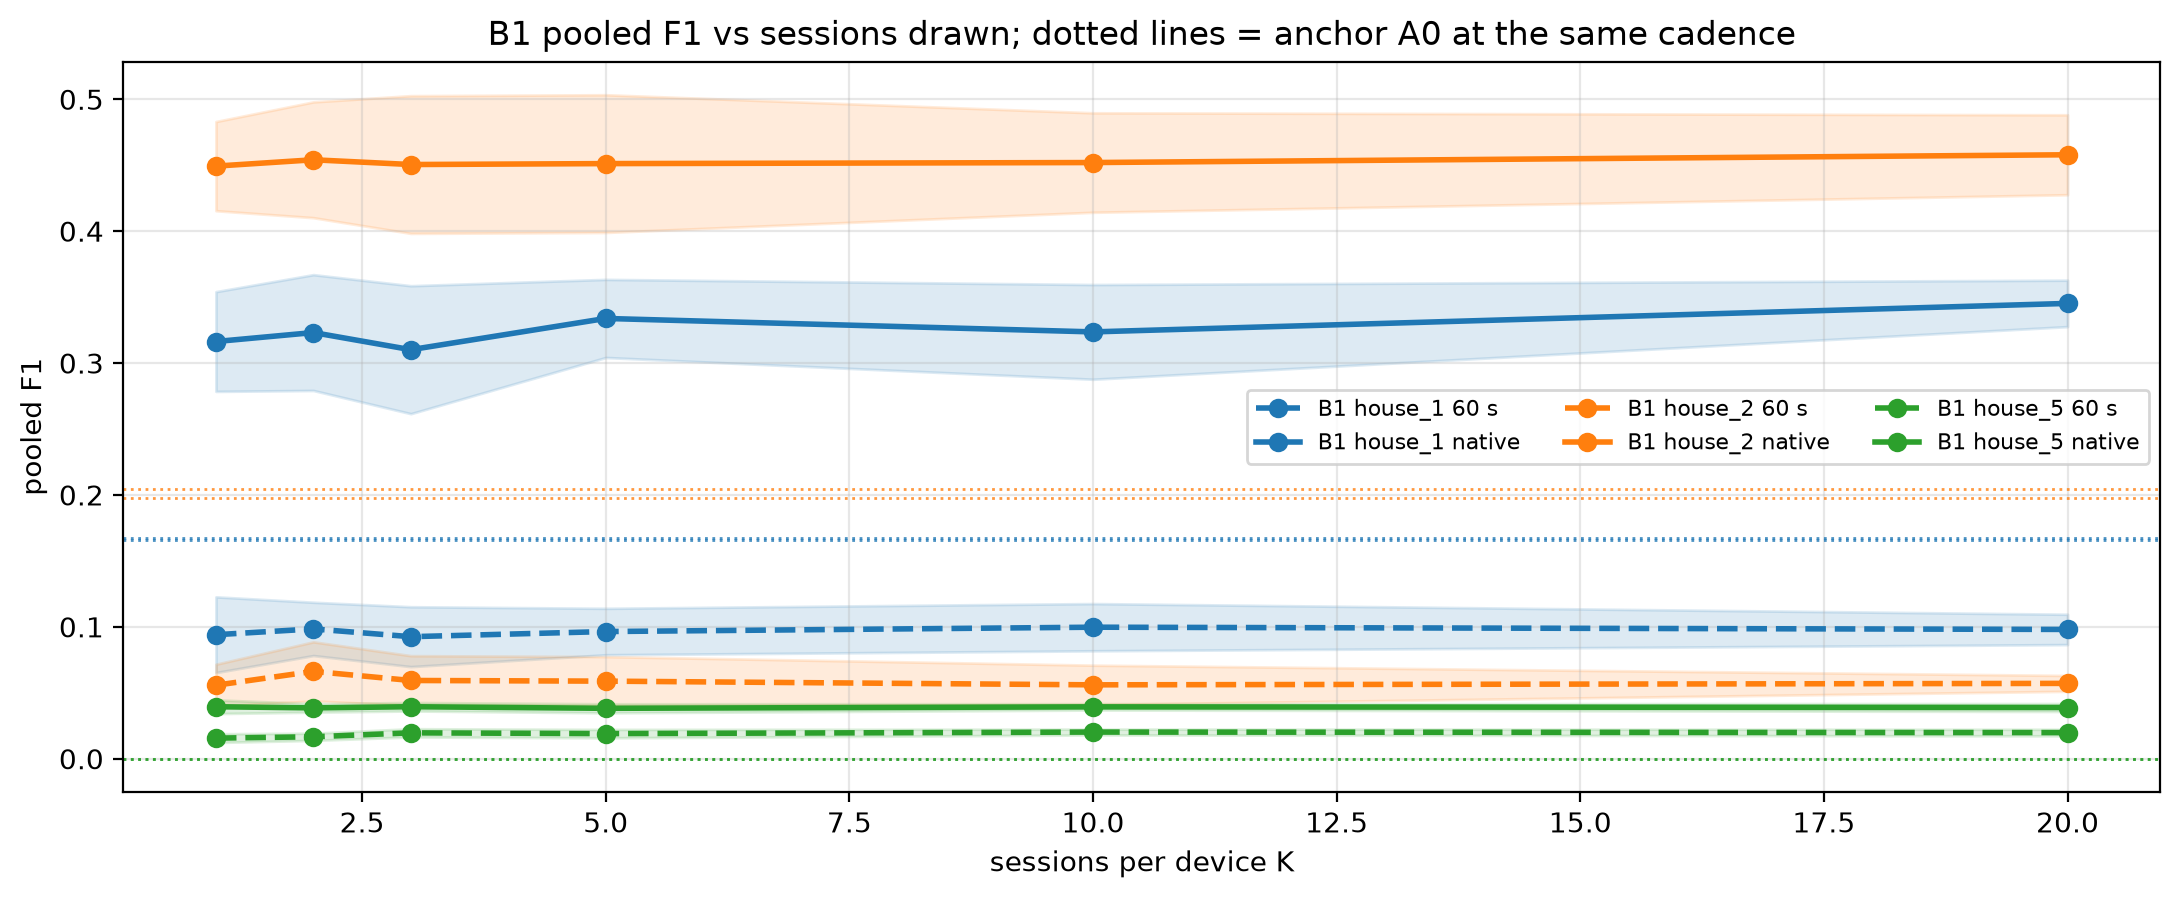

In [ ]:
# --- Figure A: the K-curve (H01, FHMM form) ------------------------------
_fig, _ax = plt.subplots(figsize=(11, 4.6))
if len(kcurve_df):
    _hcol = {"house_1": "tab:blue", "house_2": "tab:orange", "house_5": "tab:green"}
    for (_h, _cad), _g in kcurve_df.groupby(["house", "cad"]):
        _base = _hcol.get(_h, "tab:gray")
        _style = "-" if _cad == "native" else "--"
        _f1s = _g.sort_values("k")
        _ax.plot(_f1s.k, _f1s.f1, _style, color=_base, lw=2, marker="o",
                 label="B1 " + _h + (" native" if _cad == "native" else " 60 s"))
        _ax.fill_between(_f1s.k, _f1s.f1 - _f1s.f1_std, _f1s.f1 + _f1s.f1_std,
                         color=_base, alpha=0.15)
        _af = _f1s.anchor_f1.dropna()
        if len(_af):
            _ax.axhline(float(_af.iloc[0]), color=_base, lw=1, ls=":", alpha=0.8)
    _ax.set_xlabel("sessions per device K")
    _ax.set_ylabel("pooled F1")
    _ax.set_title("B1 pooled F1 vs sessions drawn; dotted lines = anchor A0 at the same cadence")
    _ax.legend(fontsize=8, ncol=3)
    _ax.grid(alpha=0.3)
_fig.tight_layout()
fig_kcurve = _fig
fig_kcurve  # noqa: B018  # render figure as cell output

In [ ]:
# --- Computation: tidy per-device K frame (native) -----------------------
DEV_COLOR = {"fridge": "tab:blue", "kettle": "tab:orange",
             "microwave": "tab:green", "washing_machine": "tab:red",
             "dishwasher": "tab:purple"}
_rows = []
if data_ready:
    for _h in houses:
        for _k in k_grid:
            _a = metrics[_h]["arms"]["kcurve"].get("native", {}).get(str(_k), {})
            for _dev, _v in _a.get("per_device_f1_mean", {}).items():
                _rows.append({"house": _h, "k": _k, "device": _dev, "f1": _v})
perdev_df = pd.DataFrame(_rows)

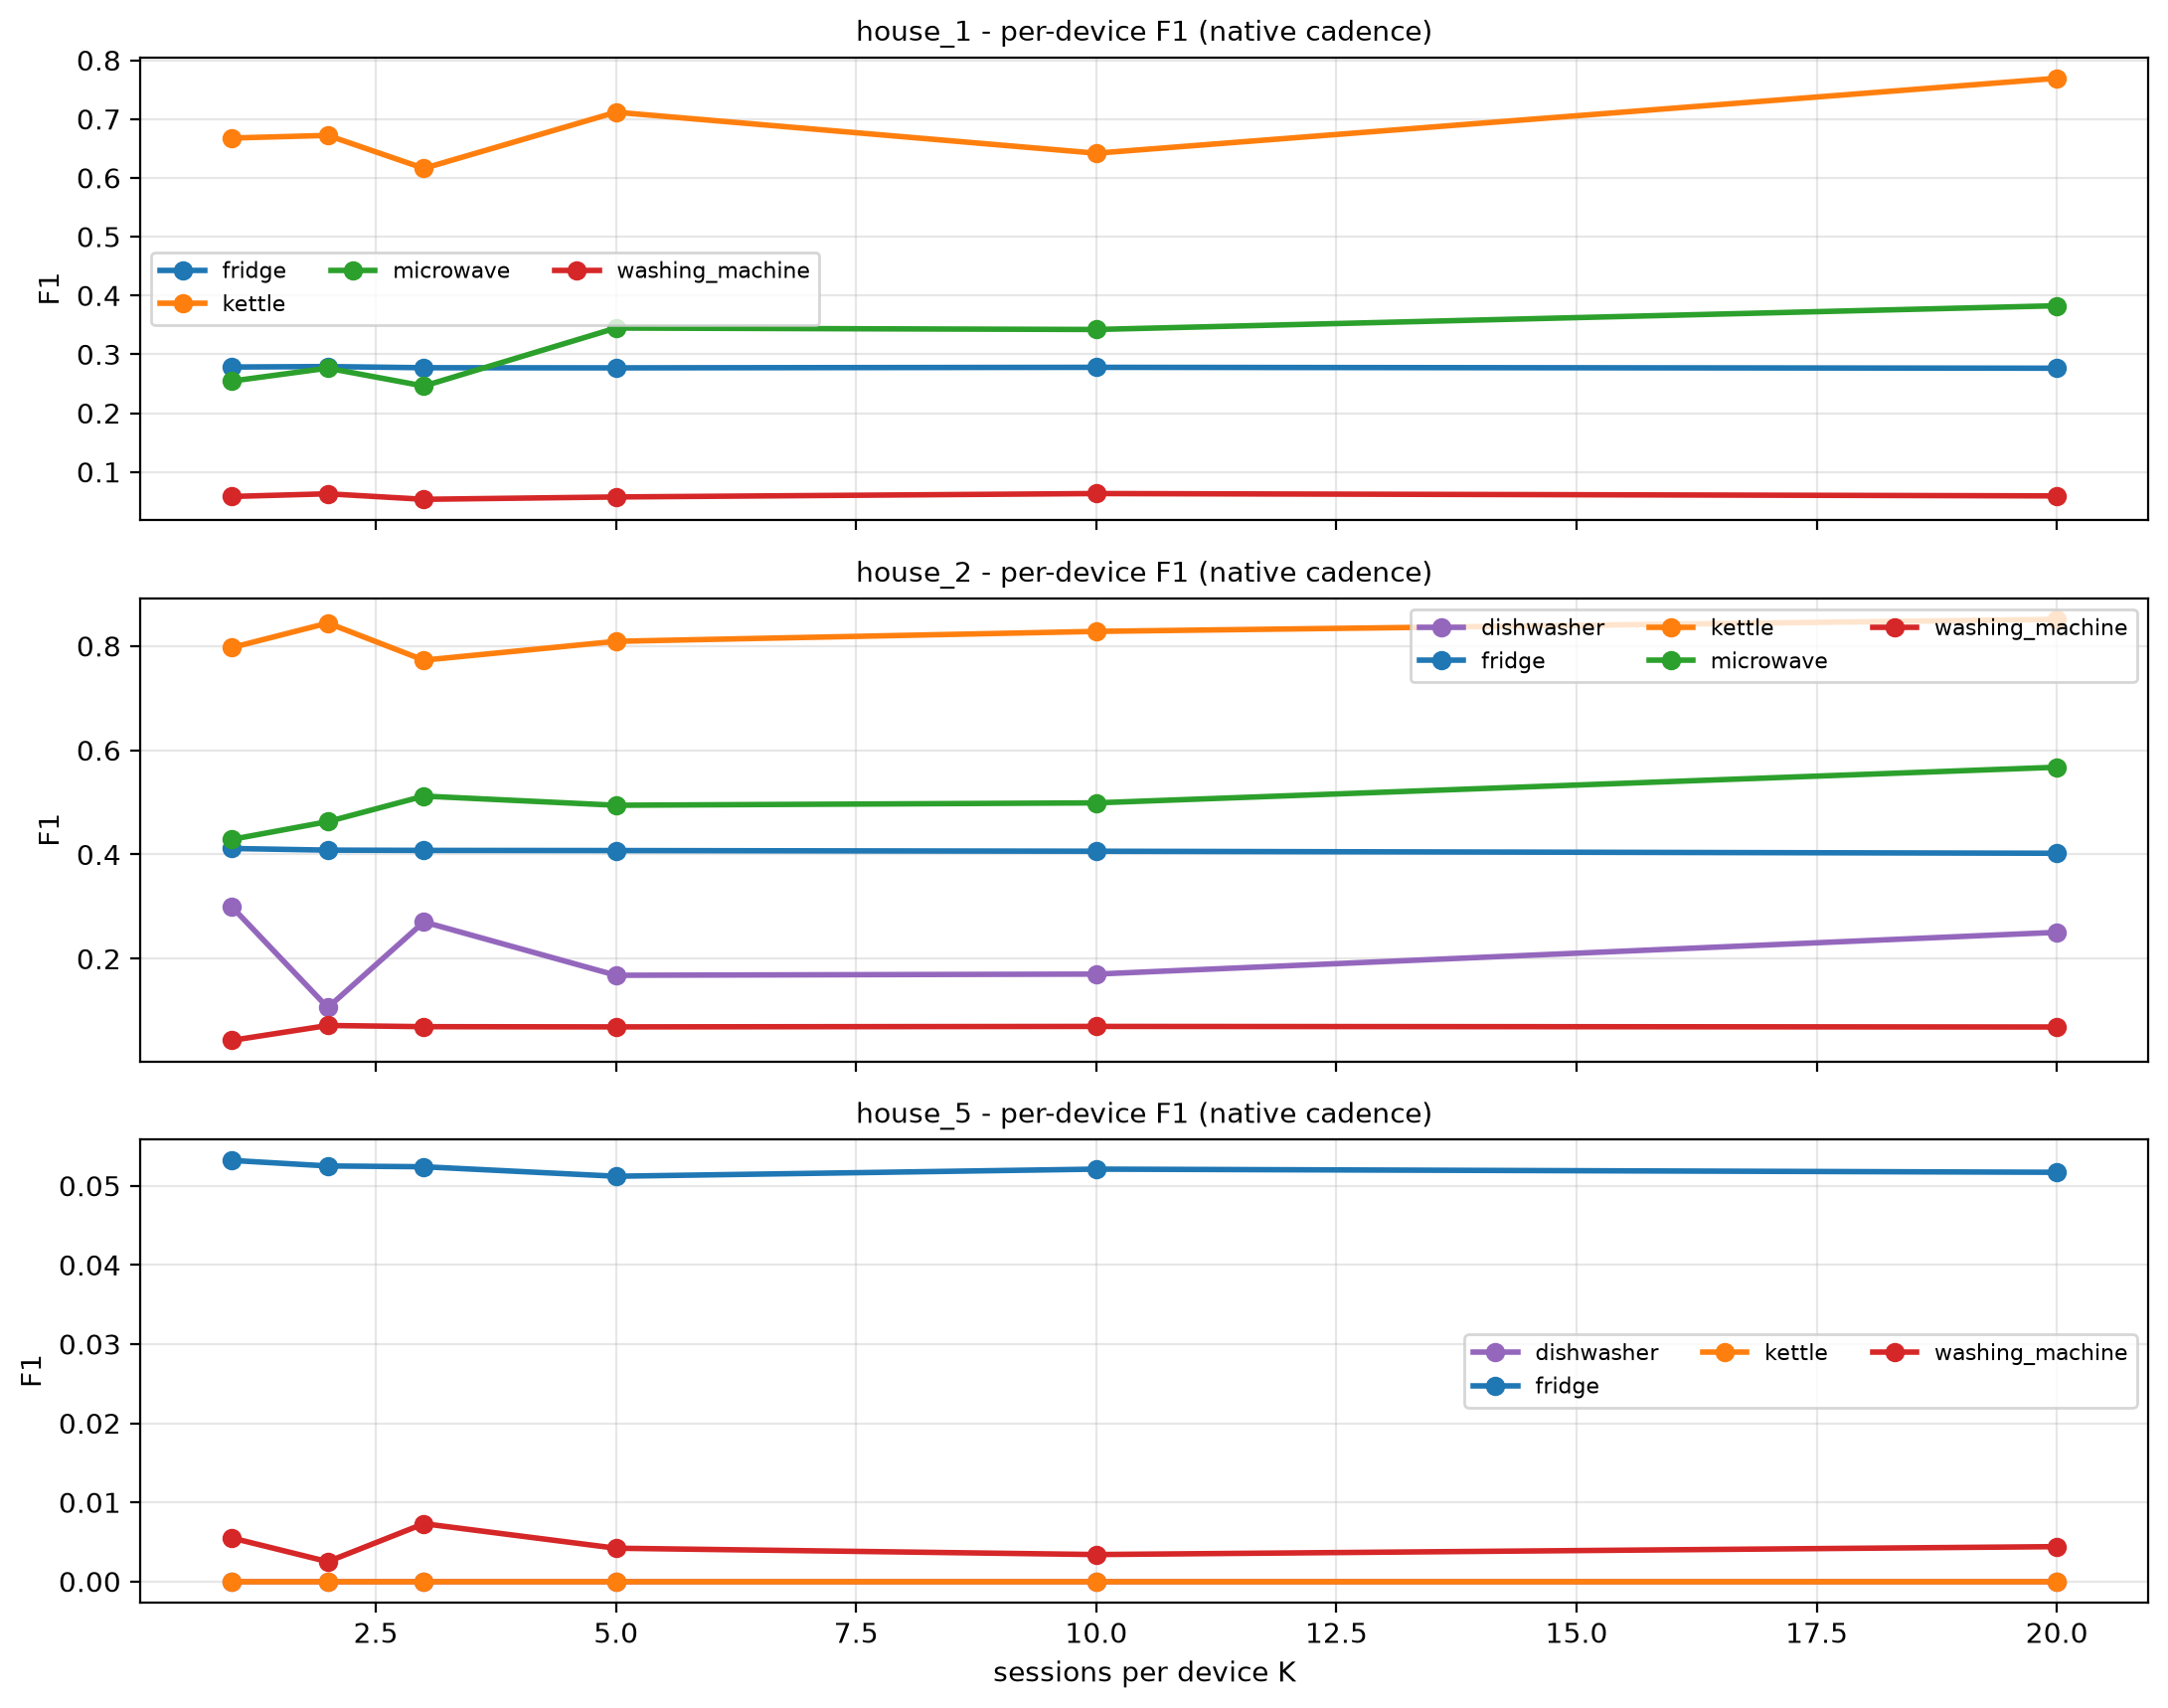

In [ ]:
# --- Figure B: per-device F1 vs K (native) -------------------------------
_n_h = max(len(houses), 1)
_fig, _axes = plt.subplots(_n_h, 1, figsize=(11, 2.9 * _n_h), sharex=True)
_axes = np.atleast_1d(_axes)
if len(perdev_df):
    for _ax, _h in zip(_axes, houses):
        for _dev in sorted(perdev_df[perdev_df.house == _h].device.unique()):
            _g = perdev_df[(perdev_df.house == _h) & (perdev_df.device == _dev)].sort_values("k")
            _ax.plot(_g.k, _g.f1, marker="o", lw=2, color=DEV_COLOR.get(_dev, "k"), label=_dev)
        _ax.set_title(_h + " - per-device F1 (native cadence)", fontsize=10)
        _ax.set_ylabel("F1")
        _ax.grid(alpha=0.3)
        _ax.legend(fontsize=8, ncol=3)
    _axes[-1].set_xlabel("sessions per device K")
_fig.tight_layout()
fig_perdev = _fig
fig_perdev  # noqa: B018  # render figure as cell output

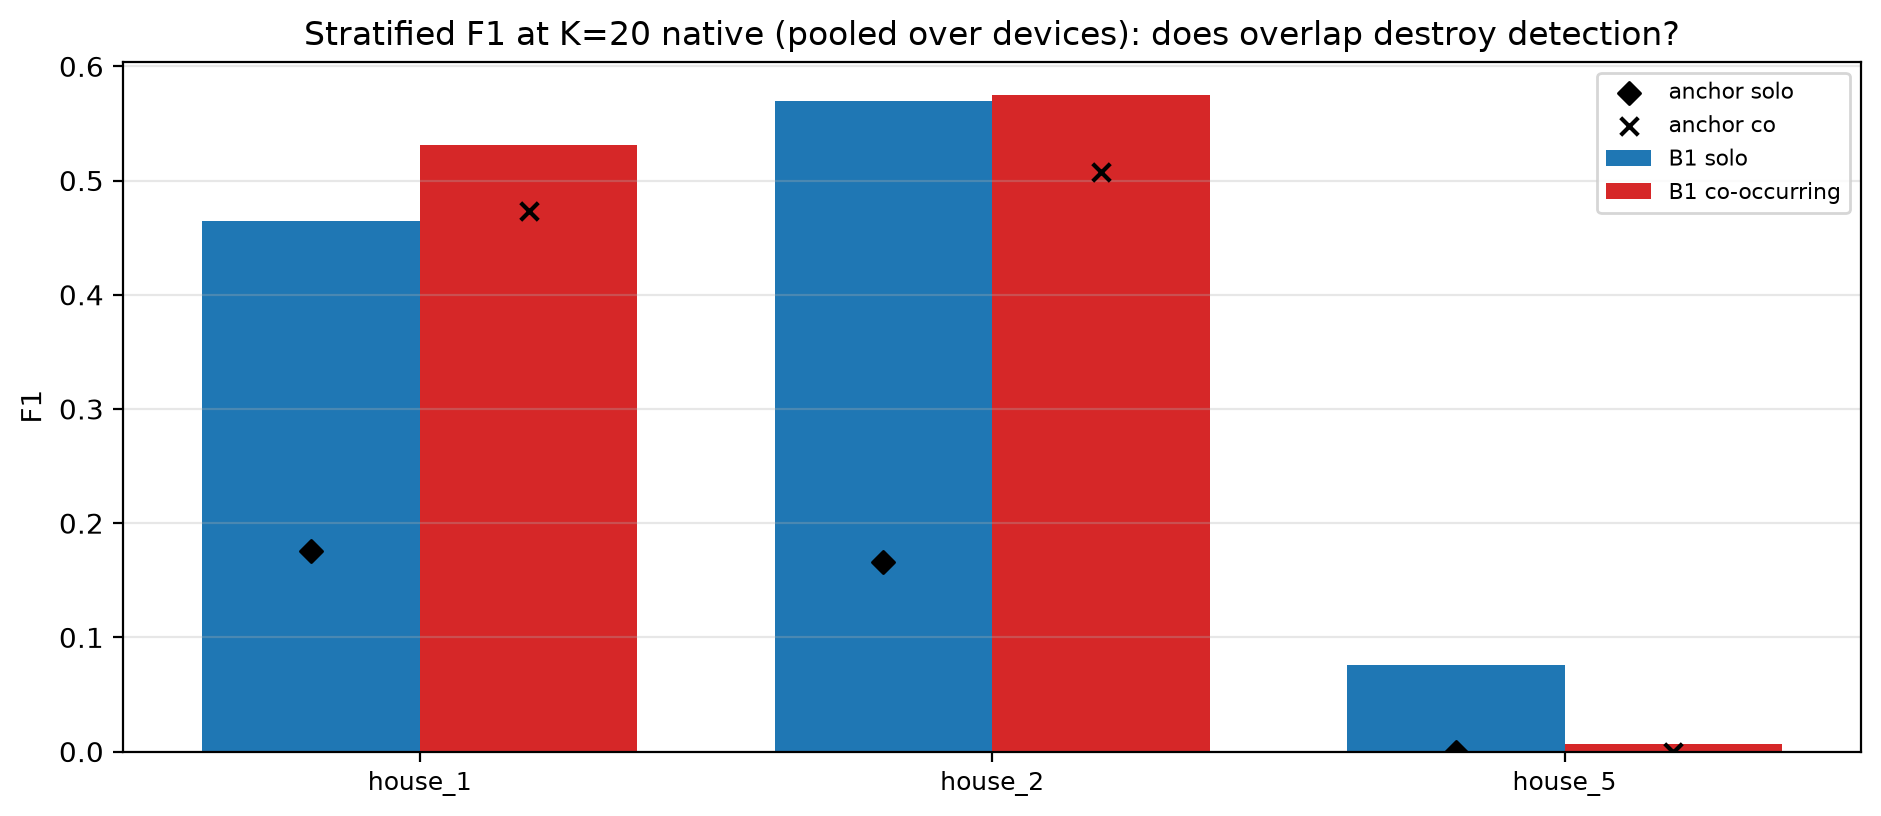

In [ ]:
# --- Figure C: solo vs co-occurring strata at the top K ------------------
# Strata: a GT episode is solo when no other enrolled device has a GT
# episode overlapping it; predictions inherit the stratum of the GT they match.
_k_top = str(k_grid[-1])
# The runner pools strata over devices inside each draw, so B1's
# strata_f1_mean carries the same pooled value under every device key;
# plot it once per house. The anchor's strata are pooled the same way
# (its JSON stores {n_pred, n_gt, n_matched, precision, recall, f1}).
_hlab, _solo_v, _co_v, _anc_s, _anc_c = [], [], [], [], []
if data_ready:
    for _h in houses:
        _b1 = metrics[_h]["arms"]["kcurve"].get("native", {}).get(_k_top, {}).get("strata_f1_mean", {})
        _an = metrics[_h]["arms"]["anchor"].get("native", {}).get("strata", {})
        _solo_v.append(np.mean([v for v in _b1.get("solo", {}).values() if v is not None])
                       if _b1.get("solo") else None)
        _co_v.append(np.mean([v for v in _b1.get("co", {}).values() if v is not None])
                     if _b1.get("co") else None)
        _anc_s.append((_an.get("solo") or {}).get("f1"))
        _anc_c.append((_an.get("co") or {}).get("f1"))
        _hlab.append(_h)
_fig, _ax = plt.subplots(figsize=(9.5, 4.2))
if _hlab:
    _x = np.arange(len(_hlab))
    _wid = 0.38
    _ax.bar(_x - _wid / 2, [v or 0 for v in _solo_v], _wid, color="tab:blue", label="B1 solo")
    _ax.bar(_x + _wid / 2, [v or 0 for v in _co_v], _wid, color="tab:red", label="B1 co-occurring")
    _ax.scatter(_x - _wid / 2, [v if v is not None else np.nan for v in _anc_s],
                marker="D", color="k", s=32, zorder=5, label="anchor solo")
    _ax.scatter(_x + _wid / 2, [v if v is not None else np.nan for v in _anc_c],
                marker="x", color="k", s=40, zorder=5, label="anchor co")
    _ax.set_xticks(_x)
    _ax.set_xticklabels(_hlab, fontsize=9)
    _ax.set_ylabel("F1")
    _ax.set_title("Stratified F1 at K=" + _k_top + " native (pooled over devices): does overlap destroy detection?")
    _ax.legend(fontsize=8)
    _ax.grid(alpha=0.3, axis="y")
_fig.tight_layout()
fig_strata = _fig
fig_strata  # noqa: B018  # render figure as cell output

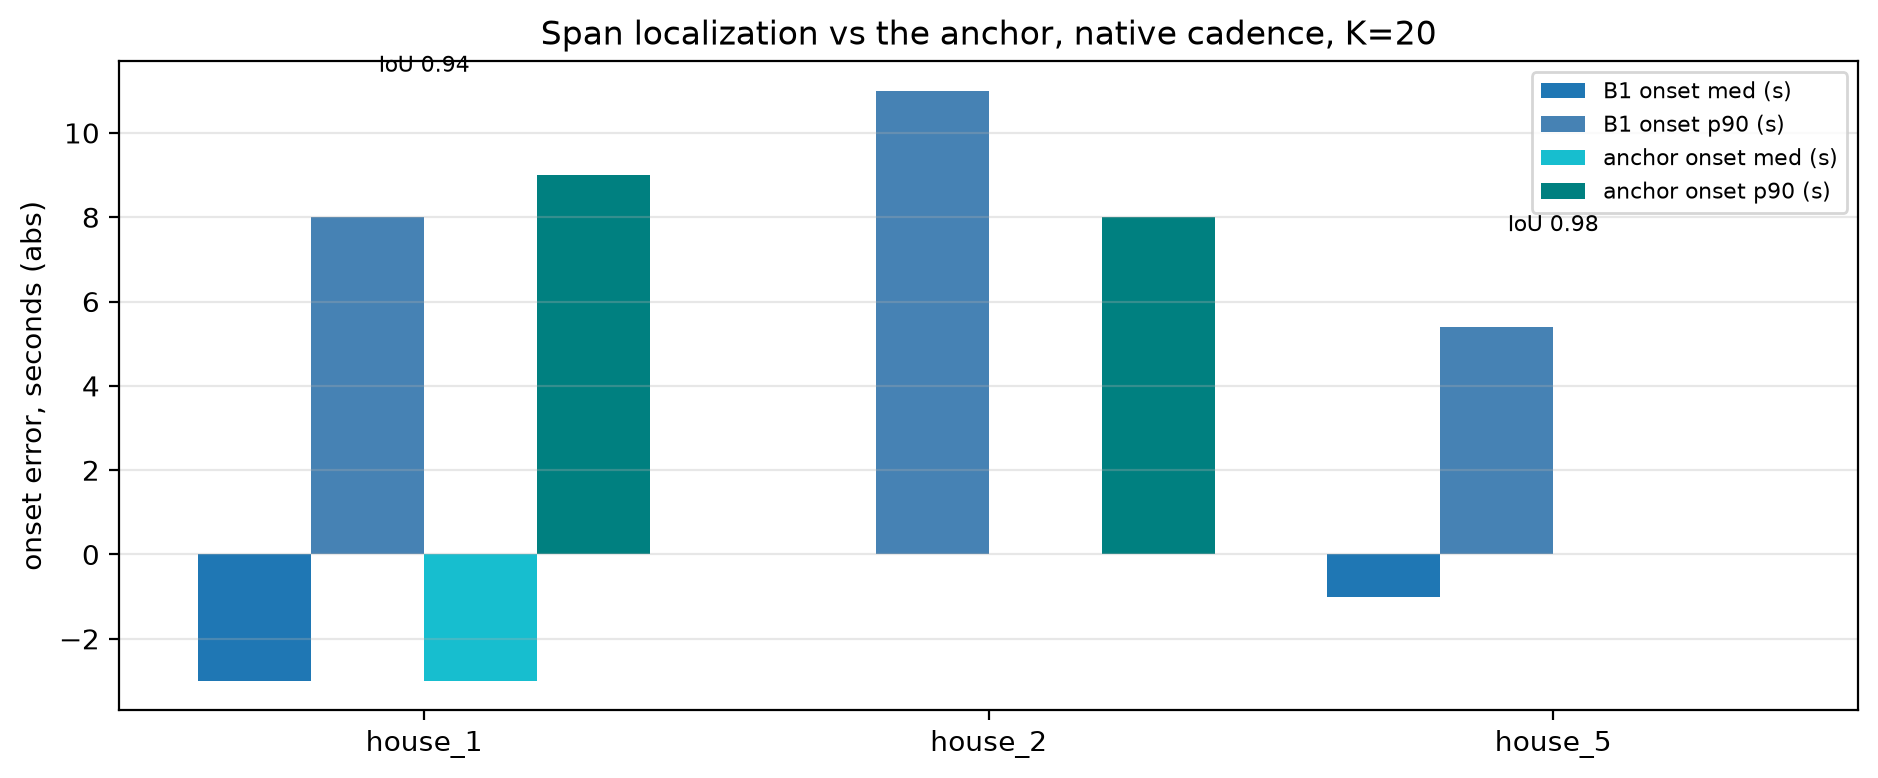

In [ ]:
# --- Figure D: span localization (onset errors + median IoU) --------------
_k_top = str(k_grid[-1])
_lab, _on_b1, _on_a, _p90_b1, _p90_a, _iou = [], [], [], [], [], []
if data_ready:
    for _h in houses:
        _b1 = metrics[_h]["arms"]["kcurve"].get("native", {}).get(_k_top, {})
        _an = metrics[_h]["arms"]["anchor"].get("native", {}).get("span", {})
        _lab.append(_h)
        _on_b1.append(_b1.get("onset_med_s"))
        _on_a.append(_an.get("onset_med_s"))
        _p90_b1.append(_b1.get("onset_p90_abs_s"))
        _p90_a.append(_an.get("onset_p90_abs_s"))
        _iou.append(_b1.get("iou_med_med"))
_fig, _ax = plt.subplots(figsize=(9.5, 4.0))
if _lab:
    _x = np.arange(len(_lab))
    _wid = 0.2
    _ax.bar(_x - 1.5 * _wid, [v or 0 for v in _on_b1], _wid, label="B1 onset med (s)", color="tab:blue")
    _ax.bar(_x - 0.5 * _wid, [v or 0 for v in _p90_b1], _wid, label="B1 onset p90 (s)", color="steelblue")
    _ax.bar(_x + 0.5 * _wid, [v or 0 for v in _on_a], _wid, label="anchor onset med (s)", color="tab:cyan")
    _ax.bar(_x + 1.5 * _wid, [v or 0 for v in _p90_a], _wid, label="anchor onset p90 (s)", color="teal")
    for _xi, _v in zip(_x, _iou):
        if _v is not None:
            _ymax = max((_p90_b1[_xi] or 0), (_p90_a[_xi] or 0))
            _ax.annotate("IoU " + str(round(_v, 2)), (_xi, _ymax * 1.05 + 2),
                         ha="center", fontsize=8)
    _ax.set_xticks(_x)
    _ax.set_xticklabels(_lab)
    _ax.set_ylabel("onset error, seconds (abs)")
    _ax.set_title("Span localization vs the anchor, native cadence, K=" + _k_top)
    _ax.legend(fontsize=8)
    _ax.grid(alpha=0.3, axis="y")
_fig.tight_layout()
fig_span = _fig
fig_span  # noqa: B018  # render figure as cell output

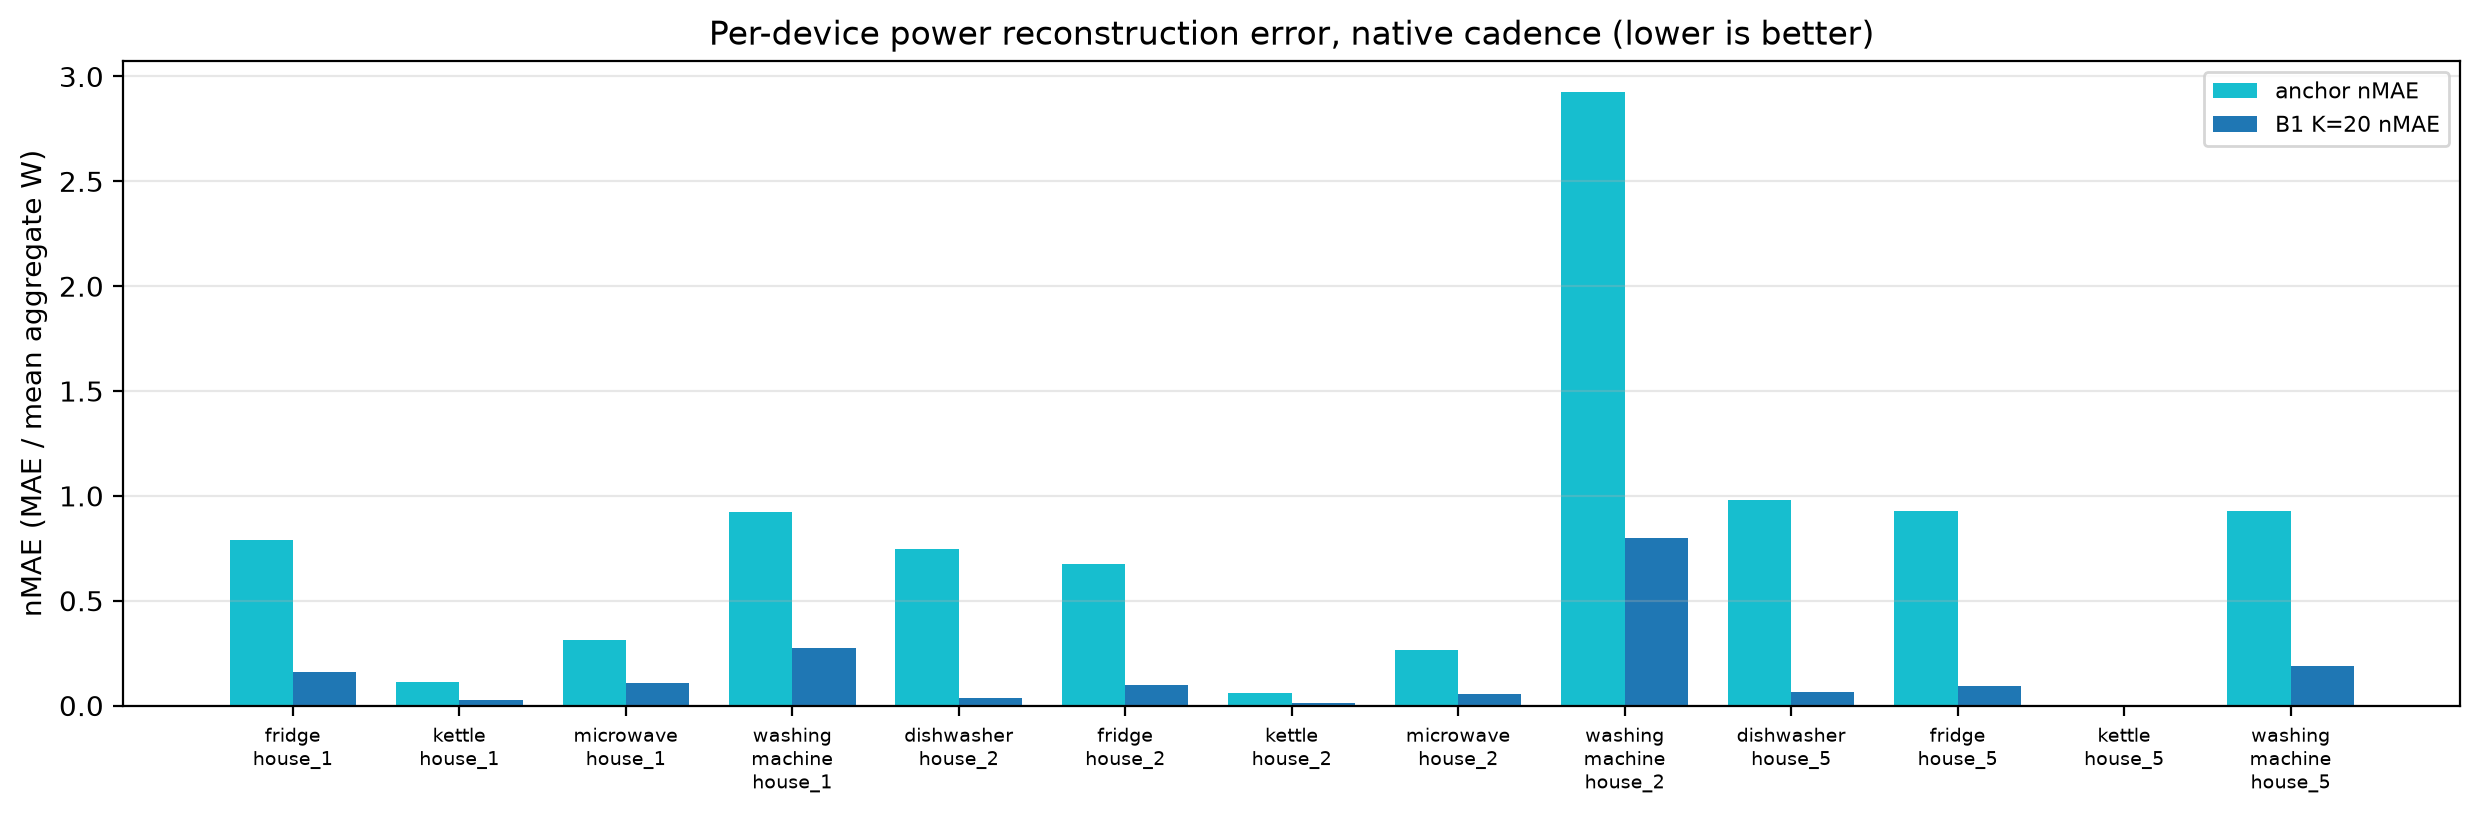

In [ ]:
# --- Figure E: regression axis, per-device nMAE ---------------------------
_k_top = str(k_grid[-1])
_devs, _hs, _nm_a, _nm_b = [], [], [], []
if data_ready:
    for _h in houses:
        _b1 = metrics[_h]["arms"]["kcurve"].get("native", {}).get(_k_top, {}).get("nmae_mean", {})
        _an = metrics[_h]["arms"]["anchor"].get("native", {}).get("axis3", {}).get("per_device", {})
        for _dev in sorted(_b1):
            _devs.append(_dev)
            _hs.append(_h)
            _nm_b.append(_b1.get(_dev))
            _nm_a.append(_an.get(_dev, {}).get("nmae"))
_fig, _ax = plt.subplots(figsize=(12.5, 4.2))
if _devs:
    _x = np.arange(len(_devs))
    _wid = 0.38
    _ax.bar(_x - _wid / 2, [v or 0 for v in _nm_a], _wid, color="tab:cyan", label="anchor nMAE")
    _ax.bar(_x + _wid / 2, [v or 0 for v in _nm_b], _wid, color="tab:blue", label="B1 K=" + _k_top + " nMAE")
    _ax.set_xticks(_x)
    _ax.set_xticklabels([d.replace("_", "\n") + "\n" + h for d, h in zip(_devs, _hs)], fontsize=7)
    _ax.set_ylabel("nMAE (MAE / mean aggregate W)")
    _ax.set_title("Per-device power reconstruction error, native cadence (lower is better)")
    _ax.legend(fontsize=8)
    _ax.grid(alpha=0.3, axis="y")
_fig.tight_layout()
fig_nmae = _fig
fig_nmae  # noqa: B018  # render figure as cell output

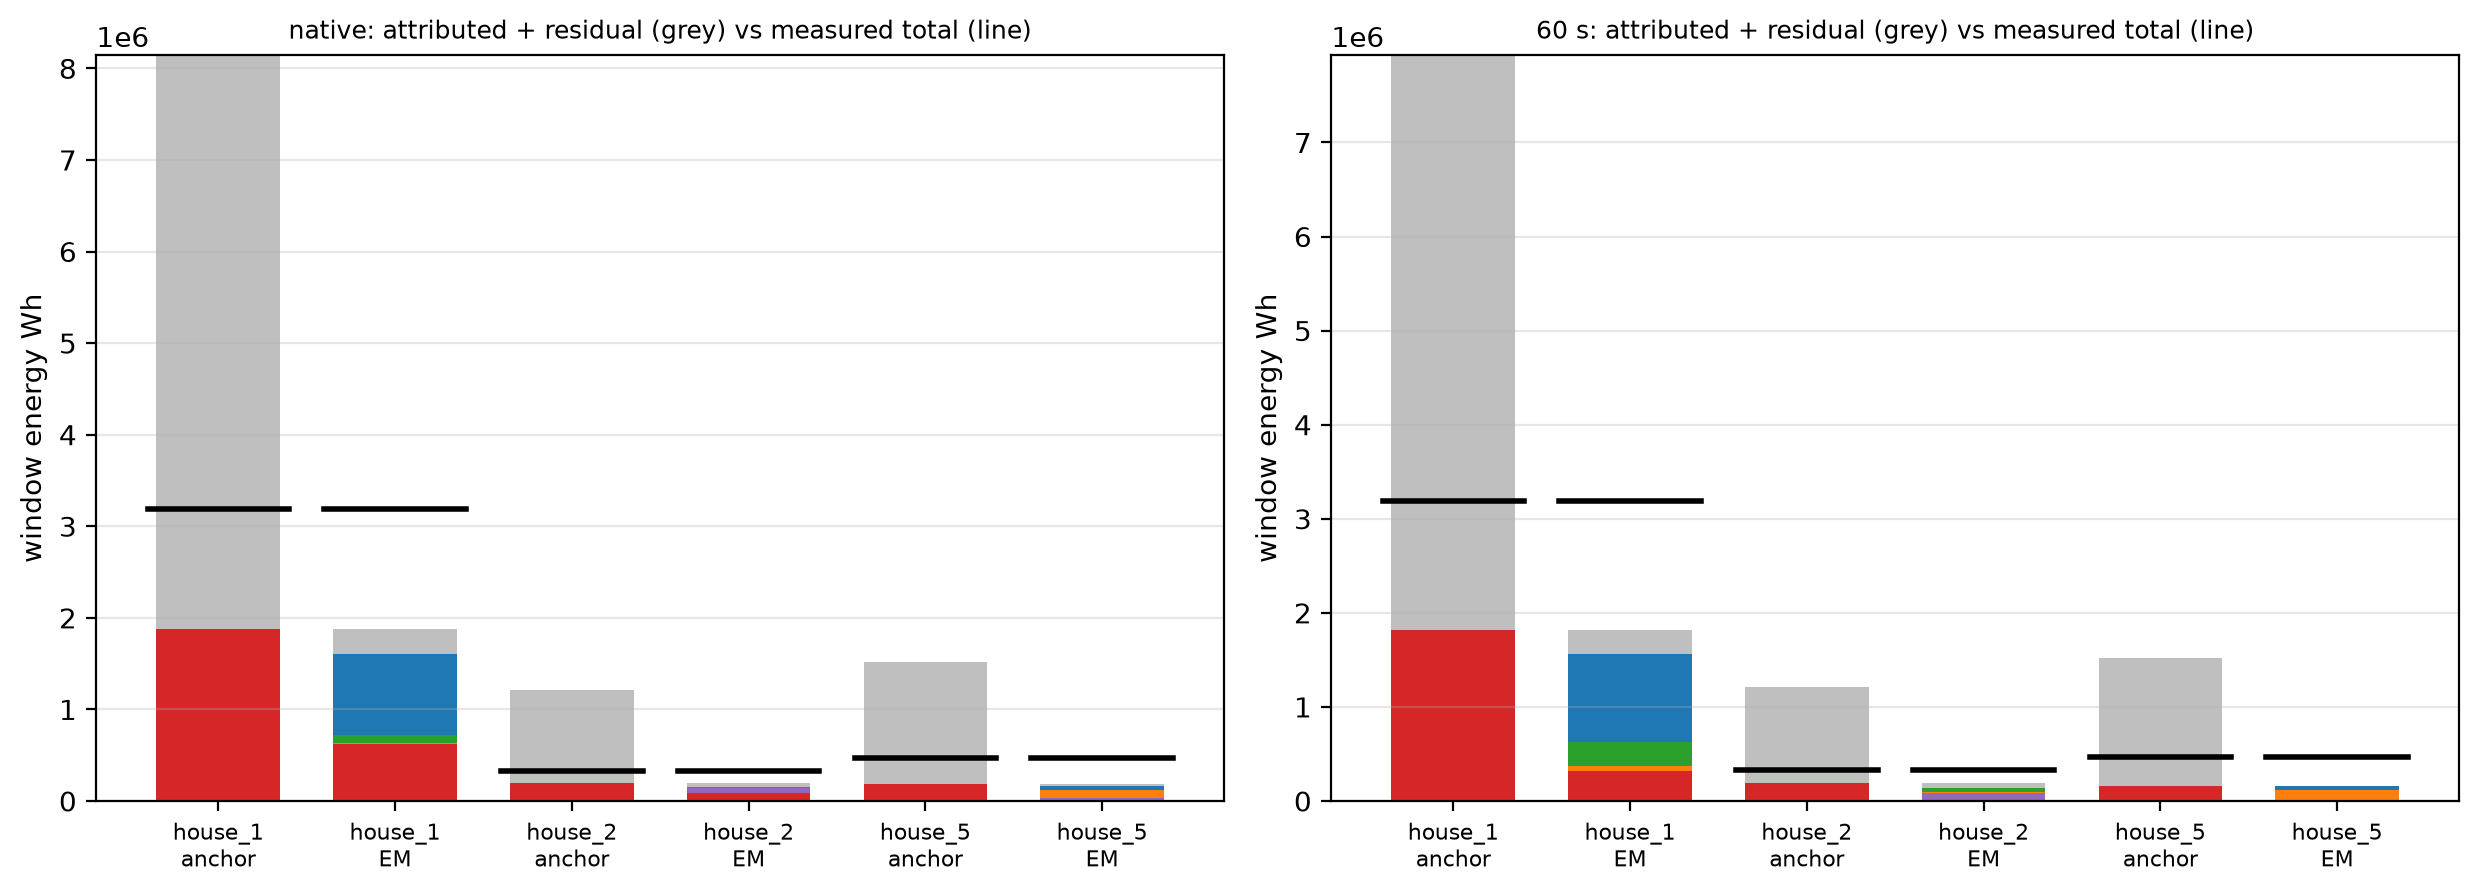

In [ ]:
# --- Figure F: books-close (H05) ------------------------------------------
# Stack: attributed per device + residual+floor (grey); black tick = the
# measured total. anchor and EM carry full per-device energy; the B1 arm
# reports its residual share in figure G (per-device energy is not stored
# for K-averaged rows).
_k_top = str(k_grid[-1])
_fig, _axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
if data_ready:
    for _ax, _cad in zip(_axes, ("native", "60")):
        _pos = 0
        _ticks, _ticklabels = [], []
        for _h in houses:
            _arms = [
                ("anchor", metrics[_h]["arms"]["anchor"].get(_cad, {}).get("axis3", {})),
                ("EM", metrics[_h]["arms"].get("em", {}).get(_cad, {}).get("axis3", {})),
            ]
            for _name, _a3 in _arms:
                _bc = _a3.get("books_close")
                if not _bc:
                    _pos += 1
                    continue
                _bot = 0.0
                for _dev, _pv in _a3.get("per_device", {}).items():
                    _e = _pv.get("energy_wh") or 0
                    _ax.bar(_pos, _e, 0.7, bottom=_bot, color=DEV_COLOR.get(_dev, "k"))
                    _bot += _e
                _resid = _bc.get("residual_wh") or 0
                _ax.bar(_pos, _resid, 0.7, bottom=_bot, color="0.75")
                _tot = _bc.get("total_wh") or 0
                _ax.plot([_pos - 0.4, _pos + 0.4], [_tot, _tot], color="k", lw=2)
                _ticks.append(_pos)
                _ticklabels.append(_h + "\n" + _name)
                _pos += 1
        _ax.set_xticks(_ticks)
        _ax.set_xticklabels(_ticklabels, fontsize=8)
        _ax.set_ylabel("window energy Wh")
        _ax.set_title(("native" if _cad == "native" else "60 s") + ": attributed + residual (grey) vs measured total (line)", fontsize=9)
        _ax.grid(alpha=0.3, axis="y")
_fig.tight_layout()
fig_books = _fig
fig_books  # noqa: B018  # render figure as cell output

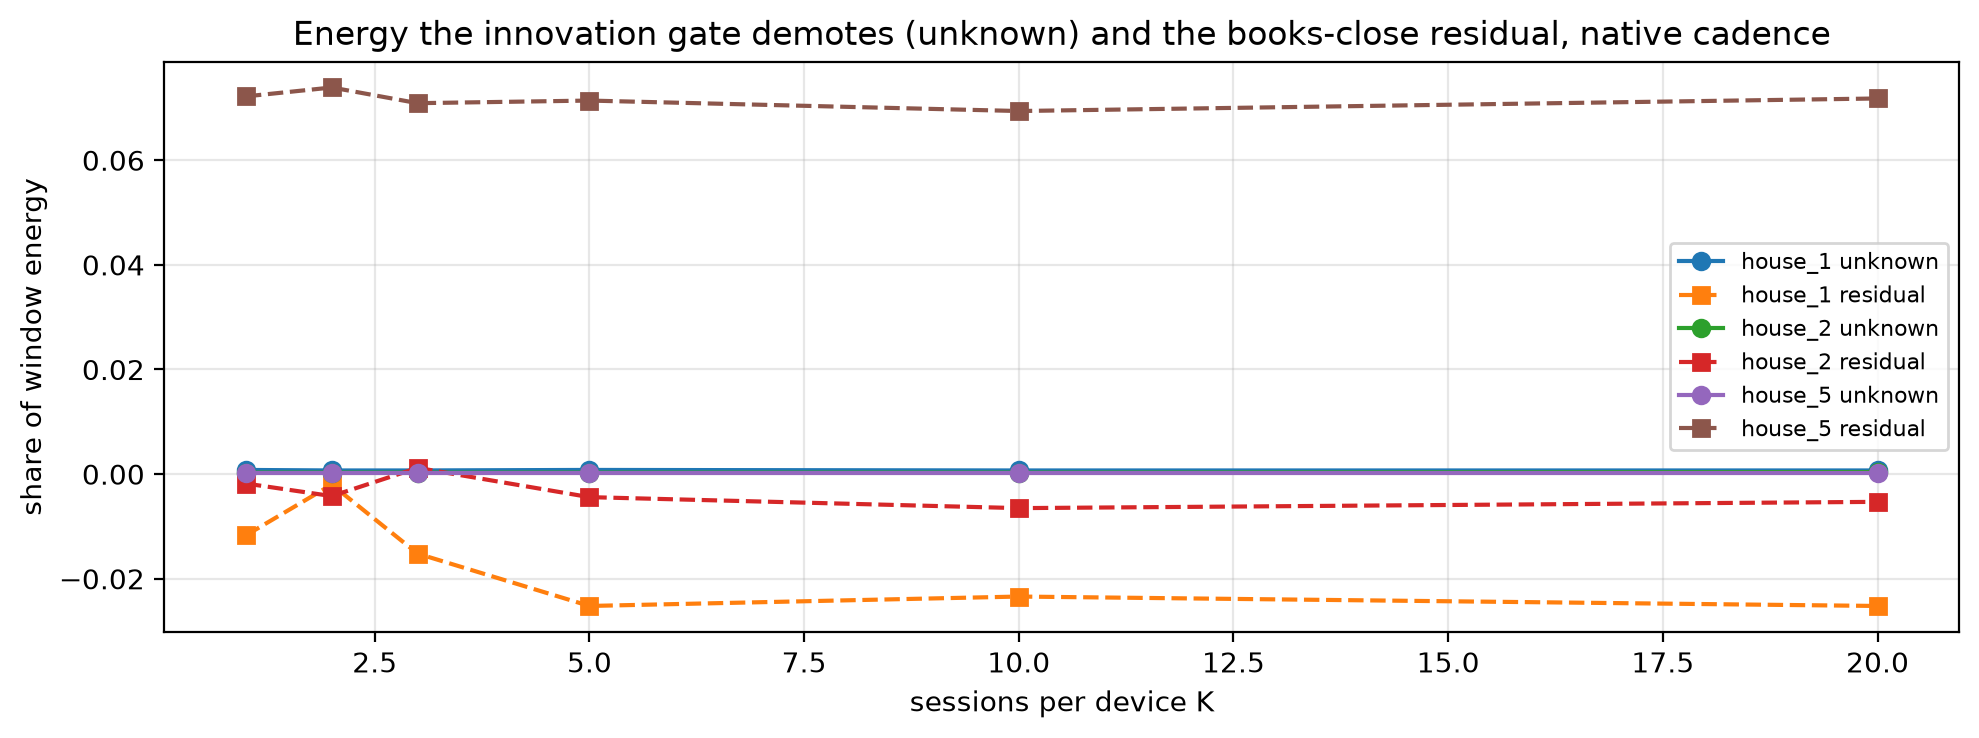

In [ ]:
# --- Figure G: gate behaviour (unknown demotion + residual share) ---------
_kur, _res = [], []
if data_ready:
    for _h in houses:
        for _k in k_grid:
            _a = metrics[_h]["arms"]["kcurve"].get("native", {}).get(str(_k), {})
            if _a:
                _kur.append({"house": _h, "k": _k, "share": _a["unknown_share_mean"]})
                _res.append({"house": _h, "k": _k, "share": _a.get("residual_share_mean")})
_fig, _ax = plt.subplots(figsize=(10, 3.8))
if _kur:
    for _h in houses:
        _pk = sorted([_r for _r in _kur if _r["house"] == _h], key=lambda _r: _r["k"])
        _ax.plot([_r["k"] for _r in _pk], [_r["share"] for _r in _pk], marker="o", label=_h + " unknown")
        _pr = sorted([_r for _r in _res if _r["house"] == _h and _r["share"] is not None], key=lambda _r: _r["k"])
        _ax.plot([_r["k"] for _r in _pr], [_r["share"] for _r in _pr], marker="s", ls="--", label=_h + " residual")
    _ax.set_xlabel("sessions per device K")
    _ax.set_ylabel("share of window energy")
    _ax.set_title("Energy the innovation gate demotes (unknown) and the books-close residual, native cadence")
    _ax.legend(fontsize=8)
    _ax.grid(alpha=0.3)
_fig.tight_layout()
fig_gate = _fig
fig_gate  # noqa: B018  # render figure as cell output

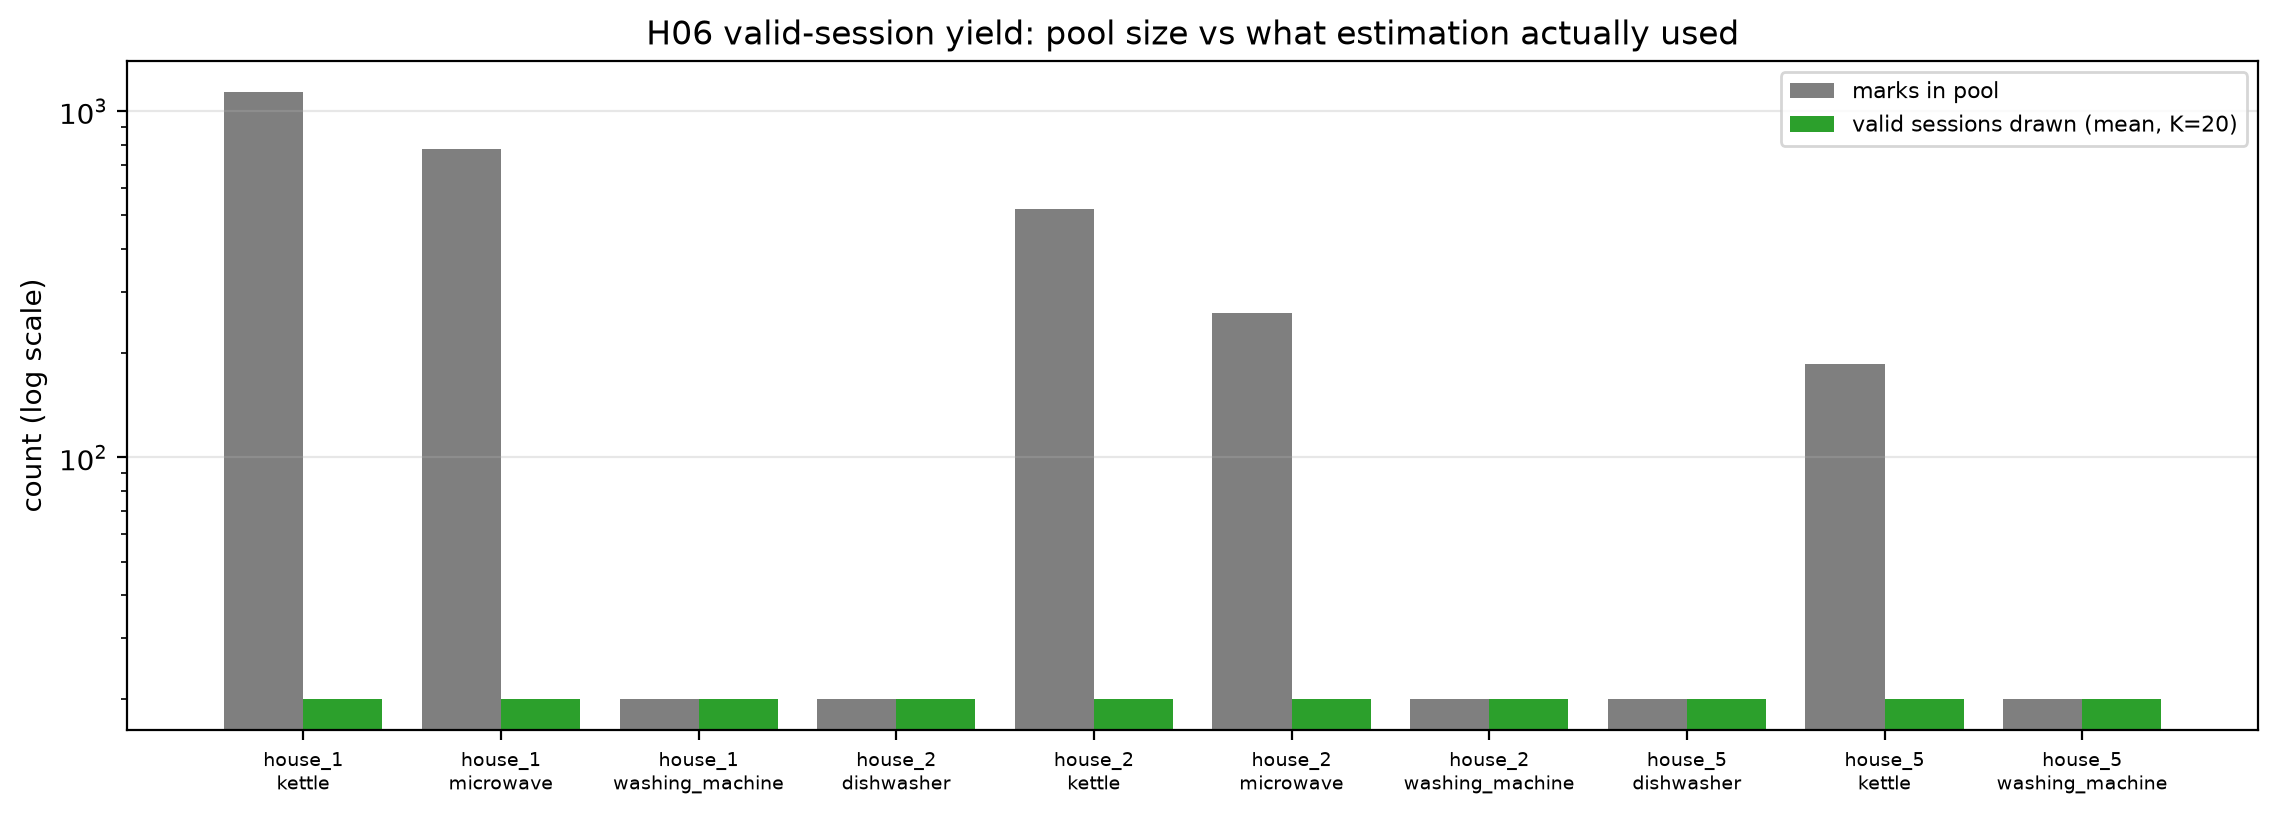

In [ ]:
# --- Figure H: session yield (H06) -----------------------------------------
_k_top = k_grid[-1]
_lab, _pool_v, _valid_v = [], [], []
if data_ready:
    for _h in houses:
        _sub = pd.DataFrame(metrics[_h].get("session_yield", []))
        if not len(_sub):
            continue
        _sub = _sub[_sub.k == _k_top]
        _pools = mech.get("houses", {}).get(_h, {}).get("devices", {})
        for _dev in sorted(_sub.device.unique()):
            _lab.append(_h + "\n" + _dev)
            _pool_v.append(_pools.get(_dev, {}).get("n_sessions"))
            _valid_v.append(float(_sub[_sub.device == _dev].valid.mean()))
_fig, _ax = plt.subplots(figsize=(11.5, 4.2))
if _lab:
    _x = np.arange(len(_lab))
    _ax.bar(_x - 0.2, [v or 0 for v in _pool_v], 0.4, color="tab:gray", label="marks in pool")
    _ax.bar(_x + 0.2, _valid_v, 0.4, color="tab:green",
            label="valid sessions drawn (mean, K=" + str(_k_top) + ")")
    _ax.set_yscale("log")
    _ax.set_xticks(_x)
    _ax.set_xticklabels(_lab, fontsize=7)
    _ax.set_ylabel("count (log scale)")
    _ax.set_title("H06 valid-session yield: pool size vs what estimation actually used")
    _ax.legend(fontsize=8)
    _ax.grid(alpha=0.3, axis="y")
_fig.tight_layout()
fig_yield = _fig
fig_yield  # noqa: B018  # render figure as cell output

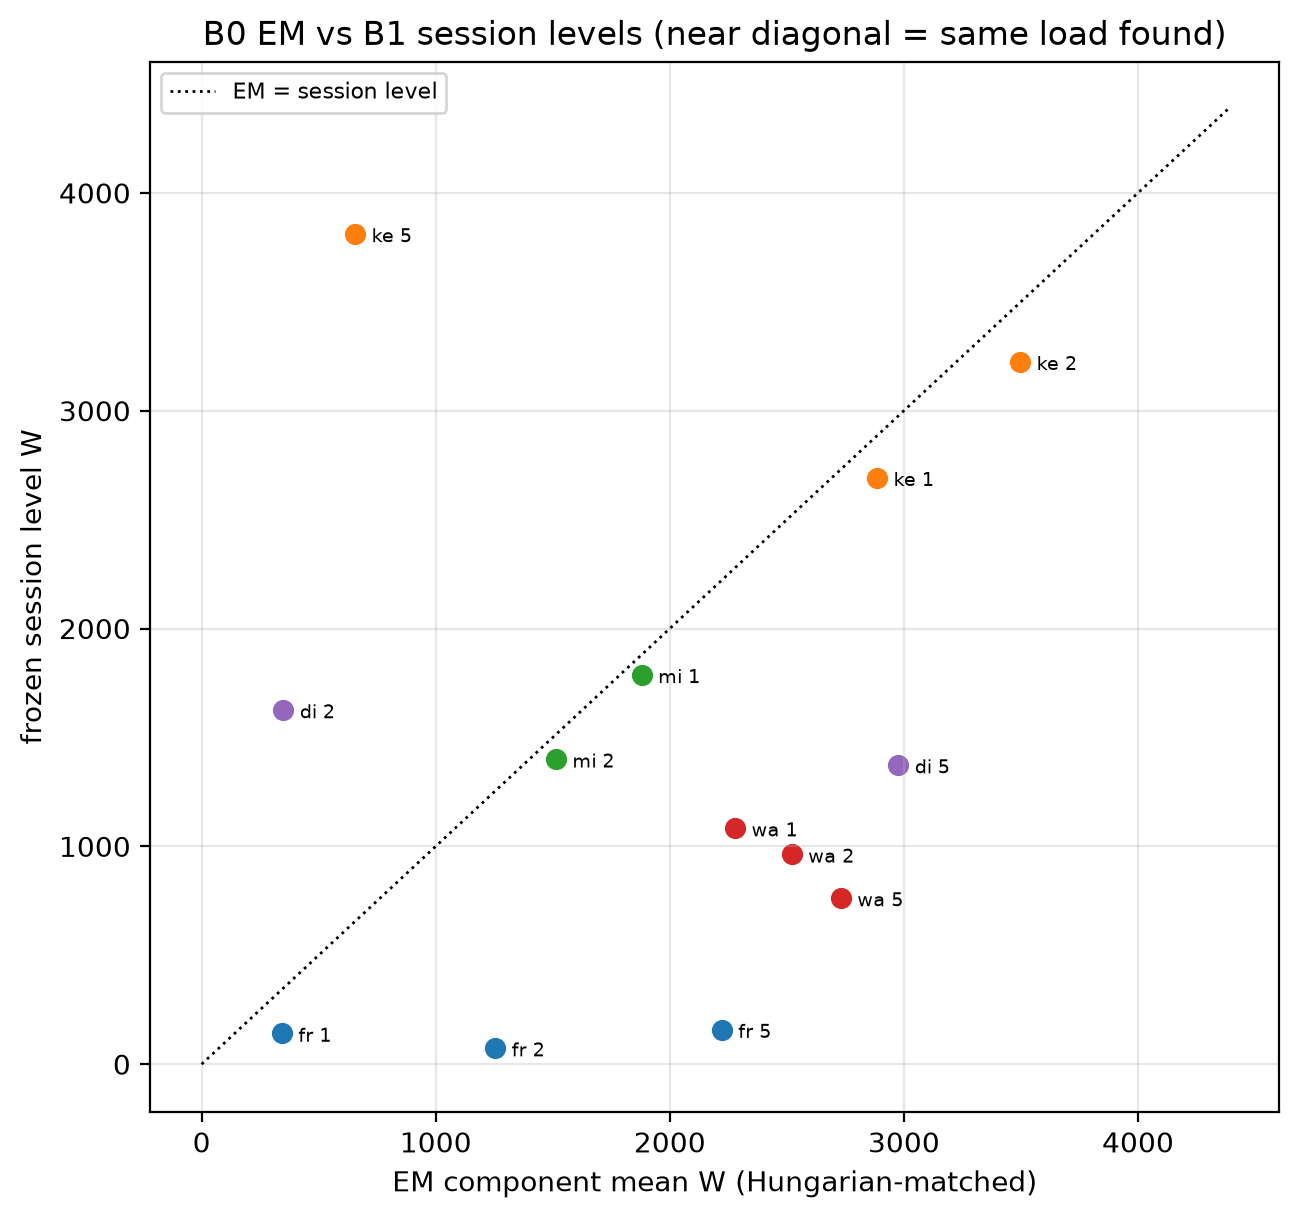

In [ ]:
# --- Figure I: EM components vs session levels (B0 vs B1) ------------------
# Hungarian-matched EM component mean (x) vs the frozen session level (y).
# Points near the diagonal: EM found the same load unsupervised.
_devc = {"fridge": "tab:blue", "kettle": "tab:orange", "microwave": "tab:green",
         "washing_machine": "tab:red", "dishwasher": "tab:purple"}
_pts = []
if data_ready:
    for _h in houses:
        _tr = metrics[_h]["arms"].get("em", {}).get("train", {})
        if not _tr:
            continue
        _comps = _tr.get("components_mu_w", [])
        for _dev, _ci in _tr.get("match_component_per_device", {}).items():
            _lv = mech.get("houses", {}).get(_h, {}).get("devices", {}).get(_dev, {}).get("level_w")
            if _ci < len(_comps) and _lv is not None:
                _pts.append({"house": _h, "device": _dev, "em_mu": _comps[_ci], "sess_mu": _lv})
_fig, _ax = plt.subplots(figsize=(6.6, 6.2))
if _pts:
    _hi = max([_p["em_mu"] for _p in _pts] + [_p["sess_mu"] for _p in _pts] + [100]) * 1.15
    _ax.plot([0, _hi], [0, _hi], "k:", lw=1, label="EM = session level")
    for _p in _pts:
        _ax.scatter([_p["em_mu"]], [_p["sess_mu"]], color=_devc.get(_p["device"], "k"), s=44)
        _ax.annotate(_p["device"][:2] + " " + _p["house"][-1], (_p["em_mu"], _p["sess_mu"]),
                     textcoords="offset points", xytext=(6, -3), fontsize=7)
    _ax.set_xlabel("EM component mean W (Hungarian-matched)")
    _ax.set_ylabel("frozen session level W")
    _ax.set_title("B0 EM vs B1 session levels (near diagonal = same load found)")
    _ax.legend(fontsize=8)
    _ax.grid(alpha=0.3)
_fig.tight_layout()
fig_em = _fig
fig_em  # noqa: B018  # render figure as cell output

## 9. The mechanism, live (synthetic)

Sections 1-8 report what happened on the real houses. This section re-runs
the estimator + decoder on synthetic data where the truth is known:

1. a synthetic 3-device additive aggregate (kettle bursts, washer and
   dishwasher programs, shared ambient), decoded with full-pool params,
2. the K-sweep on synthetic sessions - does the level estimate tighten
   as K grows, and does the decode follow?,
3. the joint-variance formula fixed pre-run (shared ambient counted once).

In [ ]:
# --- Computation: the synthetic world --------------------------------------
# Three devices, additive, 6 s cadence, ~2 days. Levels are rectangular with
# per-device spread; ambient noise is shared. Every true episode is a press
# mark (the H02 calibration simulation would hand over exactly this).
_rng = np.random.default_rng(11)
_cad = 6.0
_n_steps = 2 * 86400 // 6
_sig_off = 90.0
_floor_w = 130.0
_dev_true = {
    "kettle": {"mu": 2100.0, "sd": 40.0, "dwell_s": 150.0, "n_ep": 11},
    "washing_machine": {"mu": 750.0, "sd": 120.0, "dwell_s": 3000.0, "n_ep": 2},
    "dishwasher": {"mu": 1150.0, "sd": 260.0, "dwell_s": 5400.0, "n_ep": 2},
}
_devices = list(_dev_true)
_ts = np.arange(_n_steps, dtype=np.int64) * int(_cad * 1e6) + 1_500_000_000_000_000
_w = _rng.normal(0.0, _sig_off, _n_steps)
_truth = {d: np.zeros(_n_steps, np.int8) for d in _devices}
_pool_df = {}
for _d in _devices:
    _p = _dev_true[_d]
    _slots = np.sort(_rng.choice(
        np.arange(600, _n_steps - int(_p["dwell_s"] / _cad) - 10),
        size=_p["n_ep"], replace=False))
    _ons, _offs = [], []
    for _st in _slots:
        _n = int(_p["dwell_s"] / _cad)
        _i1 = min(_st + _n, _n_steps)
        _truth[_d][_st:_i1] = 1
        _w[_st:_i1] += _p["mu"] + _rng.normal(0.0, _p["sd"], _i1 - _st)
        _ons.append(int(_ts[_st]))
        _offs.append(int(_ts[_i1 - 1] + _cad * 1e6))
    _pool_df[_d] = pd.DataFrame({"t_on_us": _ons, "t_off_us": _offs})
_w = _w + _floor_w
synth = {"ts": _ts, "w": _w, "devices": _devices, "truth": _truth,
         "dev_true": _dev_true, "floor_w": _floor_w, "sig_off": _sig_off,
         "pool": _pool_df, "cad": _cad}

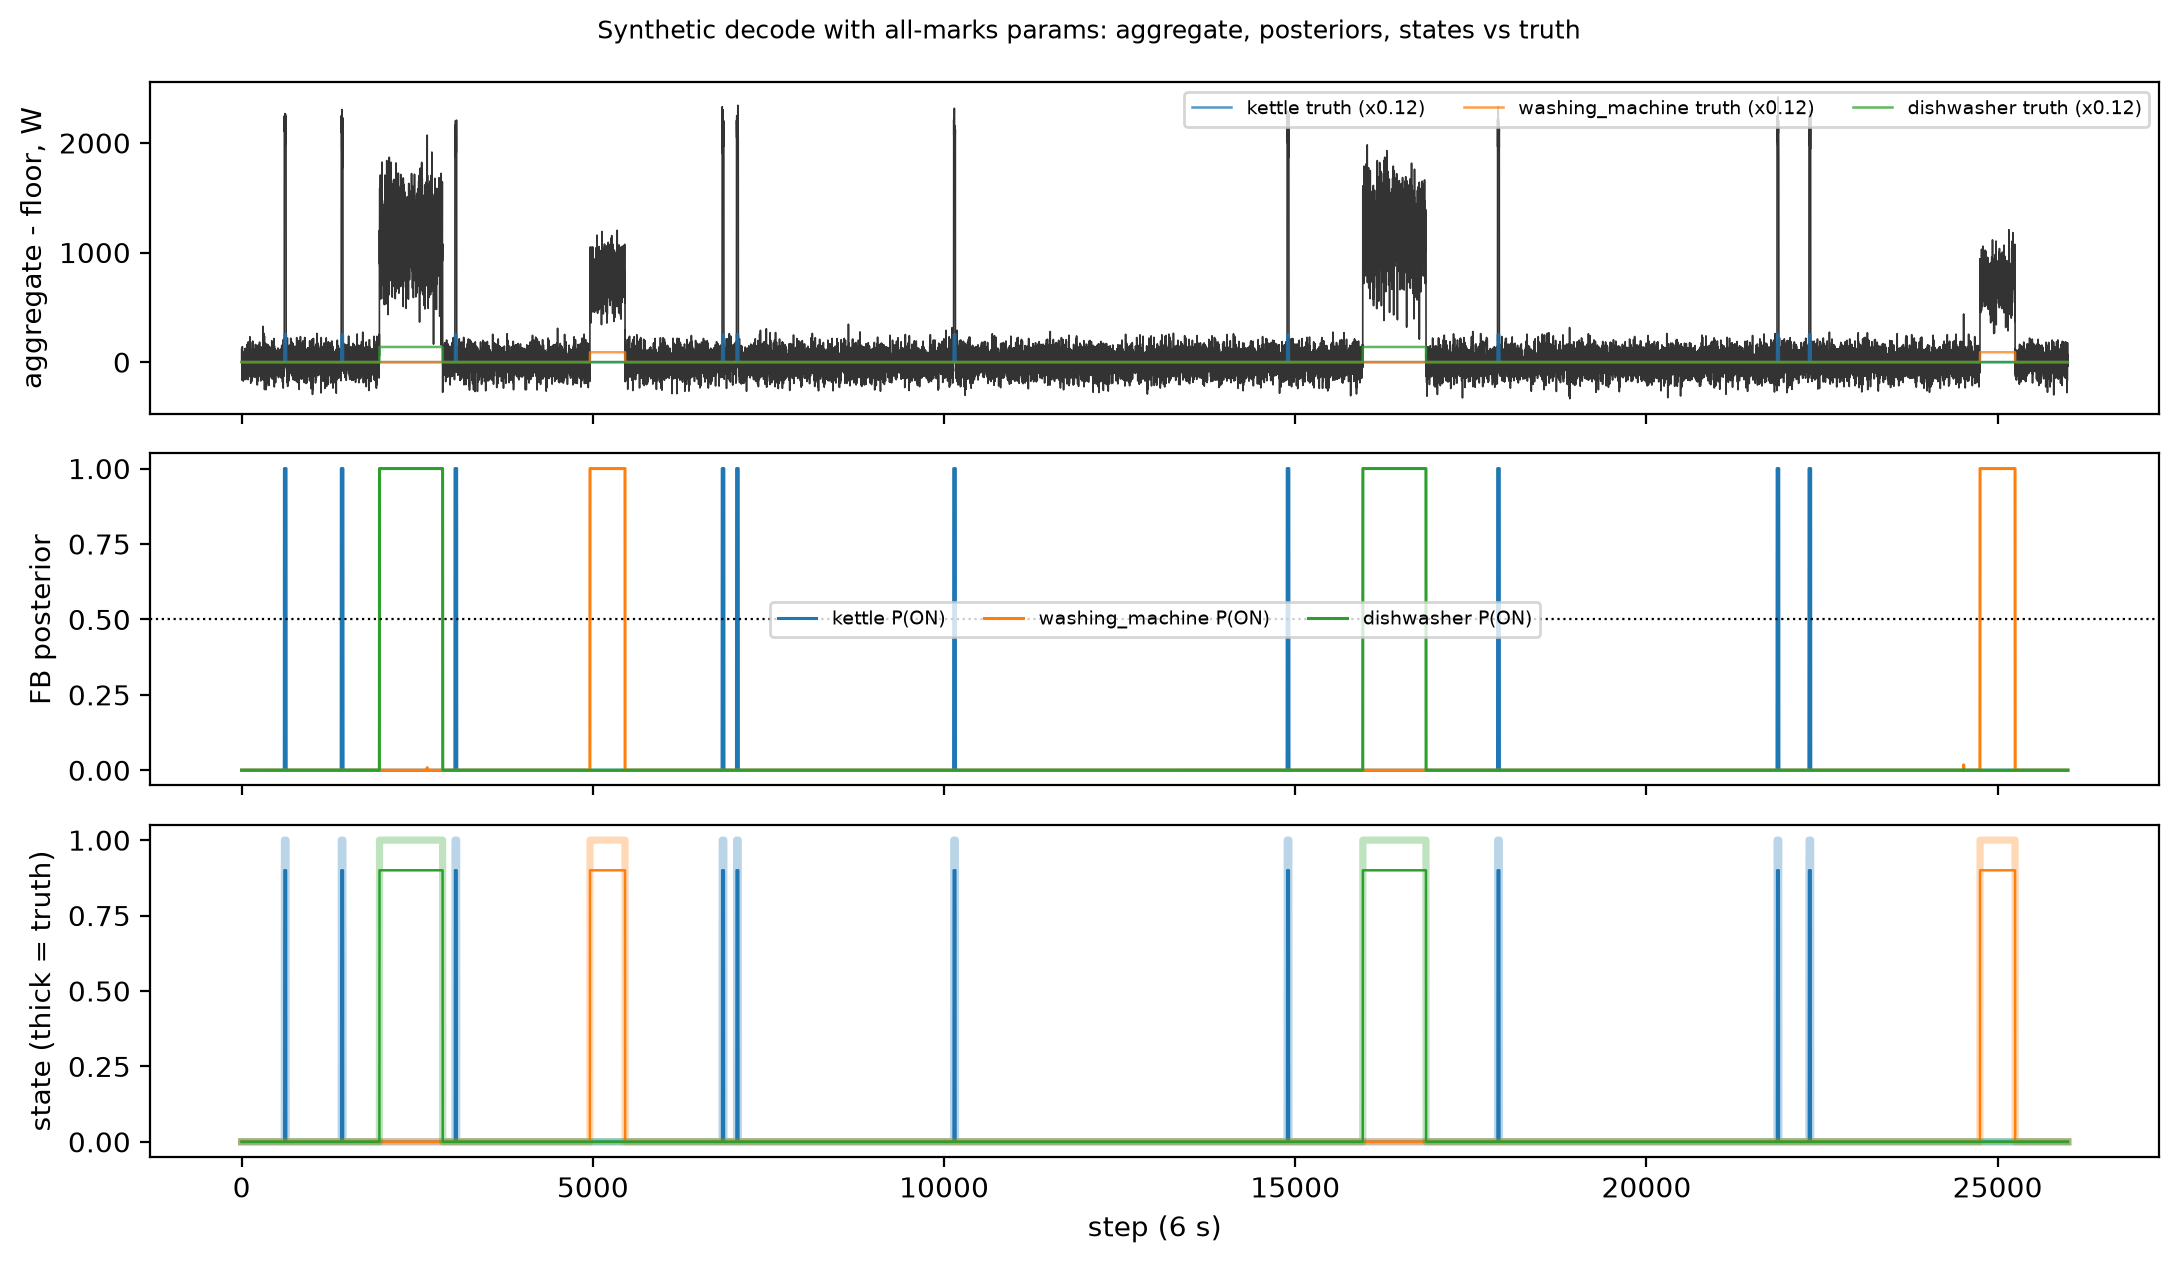

In [ ]:
# --- Computation + Figure J: full-pool decode of the synthetic world -------
_ts, _w = synth["ts"], synth["w"]
_devices = synth["devices"]
_floor_w, _sig_off = synth["floor_w"], synth["sig_off"]
_D = len(_devices)
_mu = np.zeros((1, _D), np.float32)
_sd = np.zeros((1, _D), np.float32)
_pon = np.zeros((1, _D), np.float32)
for _i, _dn in enumerate(_devices):
    _e = fl.estimate_device_params(_ts, _w, _floor_w, synth["pool"][_dn], synth["cad"])
    _mu[0, _i] = _e["mu_w"]
    _sd[0, _i] = _e["sd_w"]
    _pon[0, _i] = _e["p_on_stay"]
_params = {"mu": _mu, "sd": _sd, "p_on_stay": _pon,
           "sigma_off": np.array([_sig_off], np.float32), "floor_w": _floor_w}
dec = fl.decode_batch(_ts, _w, int(_ts[0]), int(_ts[-1]) + 1, _devices, _params, synth["cad"])
_seg = slice(0, 26000)
_fig, _axes = plt.subplots(3, 1, figsize=(11, 6.4), sharex=True)
_axes[0].plot(_w[_seg] - _floor_w, color="0.2", lw=0.6)
for _i, _dn in enumerate(_devices):
    _axes[0].plot(synth["truth"][_dn][_seg] * 0.12 * synth["dev_true"][_dn]["mu"],
                  lw=0.9, alpha=0.75, label=_dn + " truth (x0.12)")
_axes[0].set_ylabel("aggregate - floor, W")
_axes[0].legend(fontsize=7, ncol=3)
for _i, _dn in enumerate(_devices):
    _axes[1].plot(dec["marg"][_seg, 0, _i], lw=1.1, label=_dn + " P(ON)")
_axes[1].axhline(0.5, color="k", lw=0.8, ls=":")
_axes[1].set_ylabel("FB posterior")
_axes[1].legend(fontsize=7, ncol=3)
for _i, _dn in enumerate(_devices):
    _axes[2].plot(synth["truth"][_dn][_seg], lw=2.6, alpha=0.3, color="C" + str(_i))
    _axes[2].plot(dec["on"][_seg, 0, _i] * 0.9, lw=0.9, color="C" + str(_i))
_axes[2].set_ylabel("state (thick = truth)")
_axes[2].set_xlabel("step (6 s)")
_fig.suptitle("Synthetic decode with all-marks params: aggregate, posteriors, states vs truth", fontsize=9)
_fig.tight_layout()
fig_synth = _fig
fig_synth  # noqa: B018  # render figure as cell output

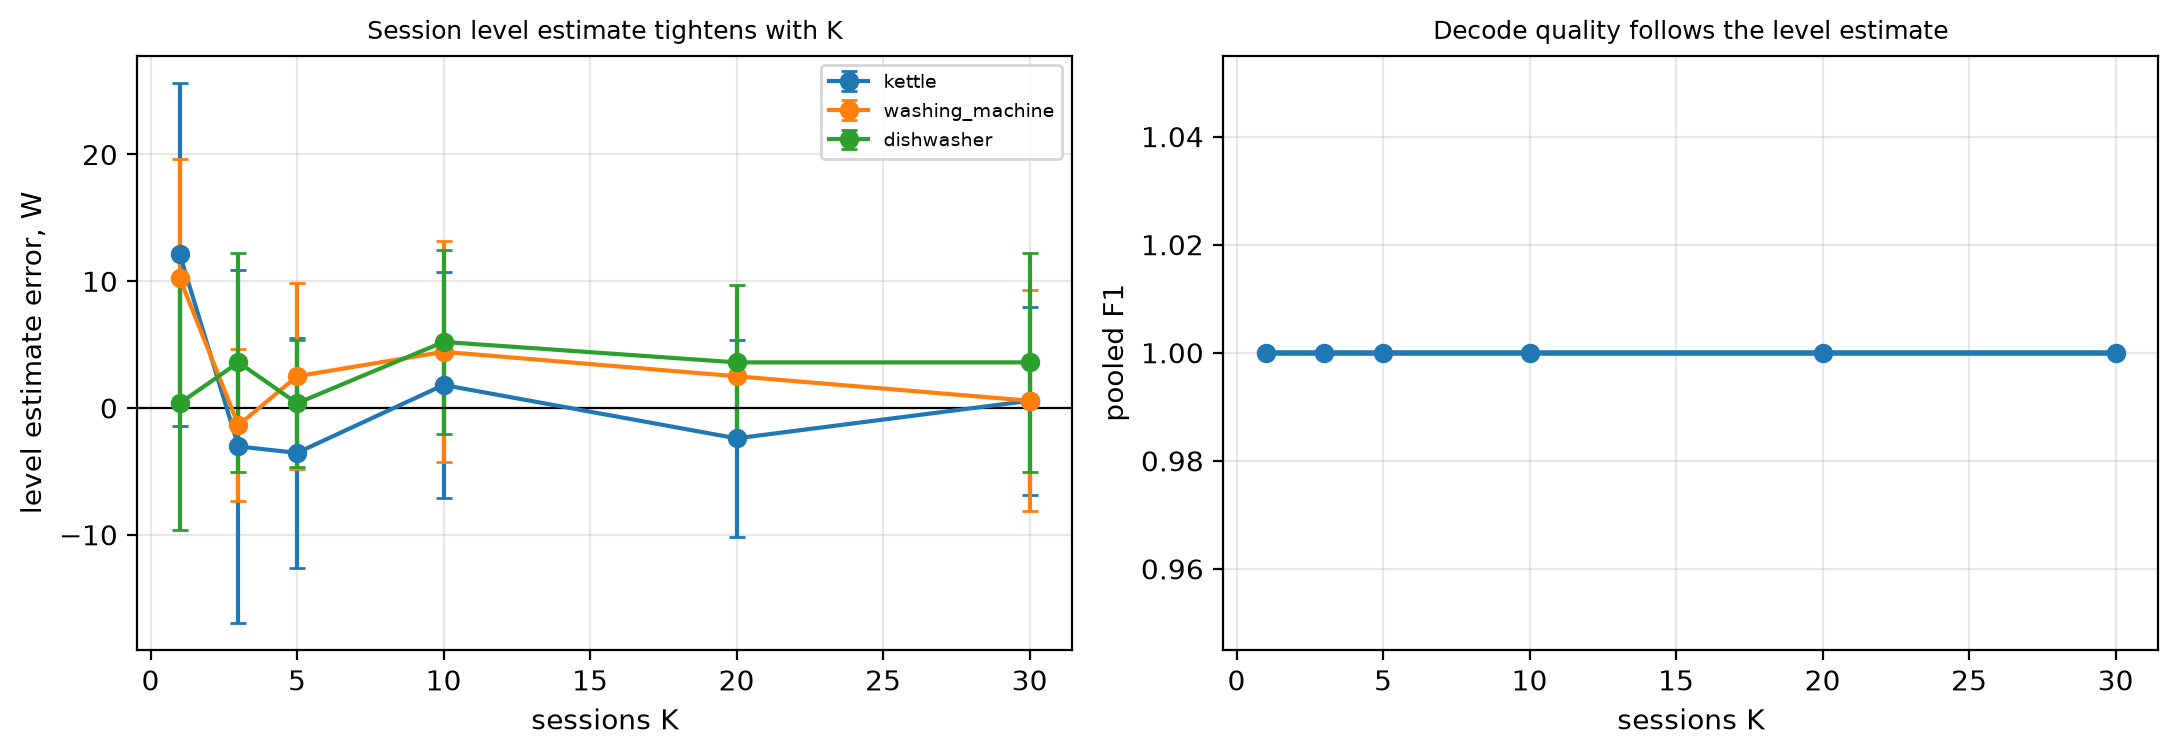

In [ ]:
# --- Computation + Figure K: the K-sweep on synthetic -----------------------
# For each K: draw K marks per device (bootstrap, with replacement), estimate
# with the real estimator, decode with the real decoder, score against truth.
_ts, _w = synth["ts"], synth["w"]
_devices = synth["devices"]
_floor_w, _sig_off = synth["floor_w"], synth["sig_off"]
_D = len(_devices)
_ks = [1, 3, 5, 10, 20, 30]
_n_rep = 6
_rng0 = np.random.default_rng(5)

def _synth_f1(_dec, _tau_s=90.0):
    _tau = int(_tau_s * 1e6)
    _dev_params = {d: {"mu_w": 0.0} for d in _devices}
    _eps = fl.spans_to_episodes(_dec, 0, _devices, _dev_params,
                                {d: 0 for d in _devices}, {d: 1 for d in _devices},
                                synth["cad"])
    _tp = _pp = _gp = 0
    for _dn in _devices:
        _pred = _eps[_eps.device == _dn]
        _gts = synth["pool"][_dn]
        _used = set()
        for _a in _pred.t_on_us:
            _pp += 1
            for _gi, _g in enumerate(_gts.t_on_us):
                if _gi not in _used and abs(int(_a) - int(_g)) <= _tau:
                    _used.add(_gi)
                    _tp += 1
                    break
        _gp += len(_gts)
    _prec = _tp / _pp if _pp else 0.0
    _rec = _tp / _gp if _gp else 0.0
    return 2 * _prec * _rec / (_prec + _rec) if _prec + _rec else 0.0

_rows = []
for _K in _ks:
    for _rep in range(_n_rep):
        _mu = np.zeros((1, _D), np.float32)
        _sd = np.zeros((1, _D), np.float32)
        _pon = np.zeros((1, _D), np.float32)
        _mu_err = {}
        for _i, _dn in enumerate(_devices):
            _pool = synth["pool"][_dn]
            _sess = _pool.iloc[_rng0.integers(0, len(_pool), size=min(_K, len(_pool)))]
            _e = fl.estimate_device_params(_ts, _w, _floor_w, _sess, synth["cad"])
            _mu_err[_dn] = (_e["mu_w"] - synth["dev_true"][_dn]["mu"]) if _e else None
            if _e is None:
                _mu[0, _i] = _floor_w
                _sd[0, _i] = fl.FROZEN["sigma_floor_w"]
                _pon[0, _i] = 1.0 - synth["cad"] / 600.0
            else:
                _mu[0, _i] = _e["mu_w"]
                _sd[0, _i] = _e["sd_w"]
                _pon[0, _i] = _e["p_on_stay"]
        _params = {"mu": _mu, "sd": _sd, "p_on_stay": _pon,
                   "sigma_off": np.array([_sig_off], np.float32), "floor_w": _floor_w}
        _dec = fl.decode_batch(_ts, _w, int(_ts[0]), int(_ts[-1]) + 1, _devices, _params, synth["cad"])
        _f1 = _synth_f1(_dec)
        for _dn in _devices:
            _rows.append({"K": _K, "rep": _rep, "device": _dn, "mu_err": _mu_err[_dn], "f1": _f1})
sweep_df = pd.DataFrame(_rows)
_agg = sweep_df.dropna(subset=["f1"]).groupby("K").f1.mean()
_fig, _axes = plt.subplots(1, 2, figsize=(11, 3.9))
for _dn in _devices:
    _sub = sweep_df[sweep_df.device == _dn].dropna(subset=["mu_err"])
    if not len(_sub):
        continue
    _m = _sub.groupby("K").mu_err.mean()
    _s = _sub.groupby("K").mu_err.std()
    _axes[0].errorbar(_m.index, _m.values, yerr=_s.values, marker="o", capsize=3, label=_dn)
_axes[0].axhline(0, color="k", lw=0.8)
_axes[0].set_xlabel("sessions K")
_axes[0].set_ylabel("level estimate error, W")
_axes[0].set_title("Session level estimate tightens with K", fontsize=9)
_axes[0].legend(fontsize=7)
_axes[0].grid(alpha=0.3)
_axes[1].plot(_agg.index, _agg.values, marker="o", color="tab:blue", lw=2)
_axes[1].set_xlabel("sessions K")
_axes[1].set_ylabel("pooled F1")
_axes[1].set_title("Decode quality follows the level estimate", fontsize=9)
_axes[1].grid(alpha=0.3)
_fig.tight_layout()
fig_sweep = _fig
fig_sweep  # noqa: B018  # render figure as cell output

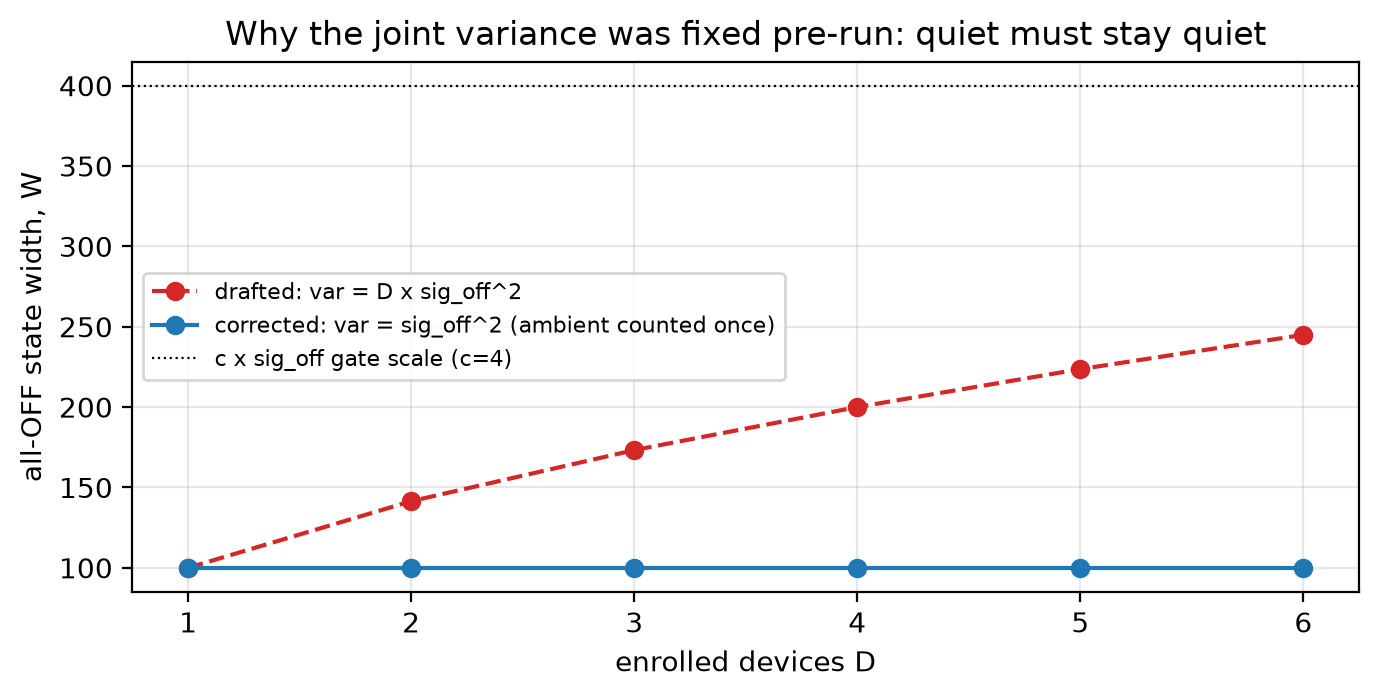

In [ ]:
# --- Figure L: the joint-variance fix, documented ---------------------------
# All-OFF width vs enrolled devices D under the drafted form (var = D*sig^2)
# vs the corrected shared-ambient form (var = sig^2). The drafted form made
# quiet widen with sqrt(D) and broke the H03 unknown rule (gate must reduce
# to c*sig_off in quiet).
_Ds = np.arange(1, 7)
_sig = 100.0
_fig, _ax = plt.subplots(figsize=(7, 3.6))
_ax.plot(_Ds, _sig * np.sqrt(_Ds), "o--", color="tab:red", label="drafted: var = D x sig_off^2")
_ax.plot(_Ds, np.full(_Ds.shape, _sig, float), "o-", color="tab:blue",
         label="corrected: var = sig_off^2 (ambient counted once)")
_ax.axhline(4 * _sig, color="k", lw=0.8, ls=":", label="c x sig_off gate scale (c=4)")
_ax.set_xlabel("enrolled devices D")
_ax.set_ylabel("all-OFF state width, W")
_ax.set_title("Why the joint variance was fixed pre-run: quiet must stay quiet")
_ax.legend(fontsize=8)
_ax.grid(alpha=0.3)
_fig.tight_layout()
fig_var = _fig
fig_var  # noqa: B018  # render figure as cell output

In [ ]:
# presentation: findings (every number pulled from the metrics)
def _fmt(_v, _nd=3):
    return "-" if _v is None else str(round(float(_v), _nd))

if not data_ready:
    _md = "Findings appear once docs/reports/fhmm/metrics_kcurve_*.json exist."
else:
    _k_top = str(k_grid[-1])
    _k_min = str(k_grid[0])
    _parts = ["## 10. Findings\n"]
    for _h in houses:
        _m = metrics[_h]["arms"]
        _a = _m["anchor"].get("native", {}).get("pooled", {}).get("f1")
        _bmin = _m["kcurve"].get("native", {}).get(_k_min, {}).get("pooled_f1_mean")
        _btop = _m["kcurve"].get("native", {}).get(_k_top, {}).get("pooled_f1_mean")
        _em = _m.get("em", {}).get("native", {}).get("pooled", {}).get("f1")
        _b60 = _m["kcurve"].get("60", {}).get(_k_top, {}).get("pooled_f1_mean")
        _a60 = _m["anchor"].get("60", {}).get("pooled", {}).get("f1")
        _unk = _m["kcurve"].get("native", {}).get(_k_top, {}).get("unknown_share_mean")
        _line = "- **" + _h + "** (H01): anchor " + _fmt(_a) + " -> B1 " + _fmt(_bmin)
        _line += " (K=" + _k_min + ") -> " + _fmt(_btop) + " (K=" + _k_top + ") native"
        if _a and _btop:
            _line += "; B1/anchor x" + str(round(_btop / _a, 1))
        _parts.append(_line)
        _parts.append("  - Cadence: rung 60 s anchor " + _fmt(_a60) + " vs B1 " + _fmt(_b60)
                      + " - the anchor transfers, the FHMM posterior spreads.")
        _parts.append("  - B0 ablation (H01 K=0 limit): EM " + _fmt(_em)
                      + ("" if _em is None else " vs B1 " + _fmt(_btop) + " - sessions carry the signal."))
        _parts.append("  - Unknown share at K=" + _k_top + ": " + _fmt(_unk) + ".")
    _md = "\n".join(_parts)
mo.md(_md)

## 10. Findings

- **house_1** (H01): anchor 0.167 -> B1 0.316 (K=1) -> 0.345 (K=20) native; B1/anchor x2.1
  - Cadence: rung 60 s anchor 0.165 vs B1 0.098 - the anchor transfers, the FHMM posterior spreads.
  - B0 ablation (H01 K=0 limit): EM 0.143 vs B1 0.345 - sessions carry the signal.
  - Unknown share at K=20: 0.001.
- **house_2** (H01): anchor 0.198 -> B1 0.449 (K=1) -> 0.458 (K=20) native; B1/anchor x2.3
  - Cadence: rung 60 s anchor 0.205 vs B1 0.057 - the anchor transfers, the FHMM posterior spreads.
  - B0 ablation (H01 K=0 limit): EM 0.084 vs B1 0.458 - sessions carry the signal.
  - Unknown share at K=20: 0.0.
- **house_5** (H01): anchor 0.0 -> B1 0.039 (K=1) -> 0.039 (K=20) native
  - Cadence: rung 60 s anchor 0.0 vs B1 0.02 - the anchor transfers, the FHMM posterior spreads.
  - B0 ablation (H01 K=0 limit): EM 0.0 vs B1 0.039 - sessions carry the signal.
  - Unknown share at K=20: 0.0.